In [6]:
import importlib
import whisky_utils
importlib.reload(whisky_utils)
from whisky_utils import *

import pandas as pd
import numpy as np
import sqlite3
import re
import warnings
warnings.filterwarnings("ignore")

conn = sqlite3.connect("whisky_auctions.db")
df_raw = pd.read_sql("""
    SELECT l.lot_id, l.title, l.winning_bid,
           l.age_years, l.distilled_date, l.bottled_date,
           l.abv, l.volume_cl, l.cask_number,
           ct.name as cask_type,
           a.auction_number
    FROM lots l
    LEFT JOIN cask_types ct ON l.cask_type_id = ct.id
    LEFT JOIN auctions a    ON l.auction_id   = a.id
""", conn)

df = enrich_dataframe(df_raw)
print(f"Ready — {len(df):,} lots loaded and enriched")

Applying enrichment...
Done. 115,561 lots enriched.
Ready — 115,561 lots loaded and enriched


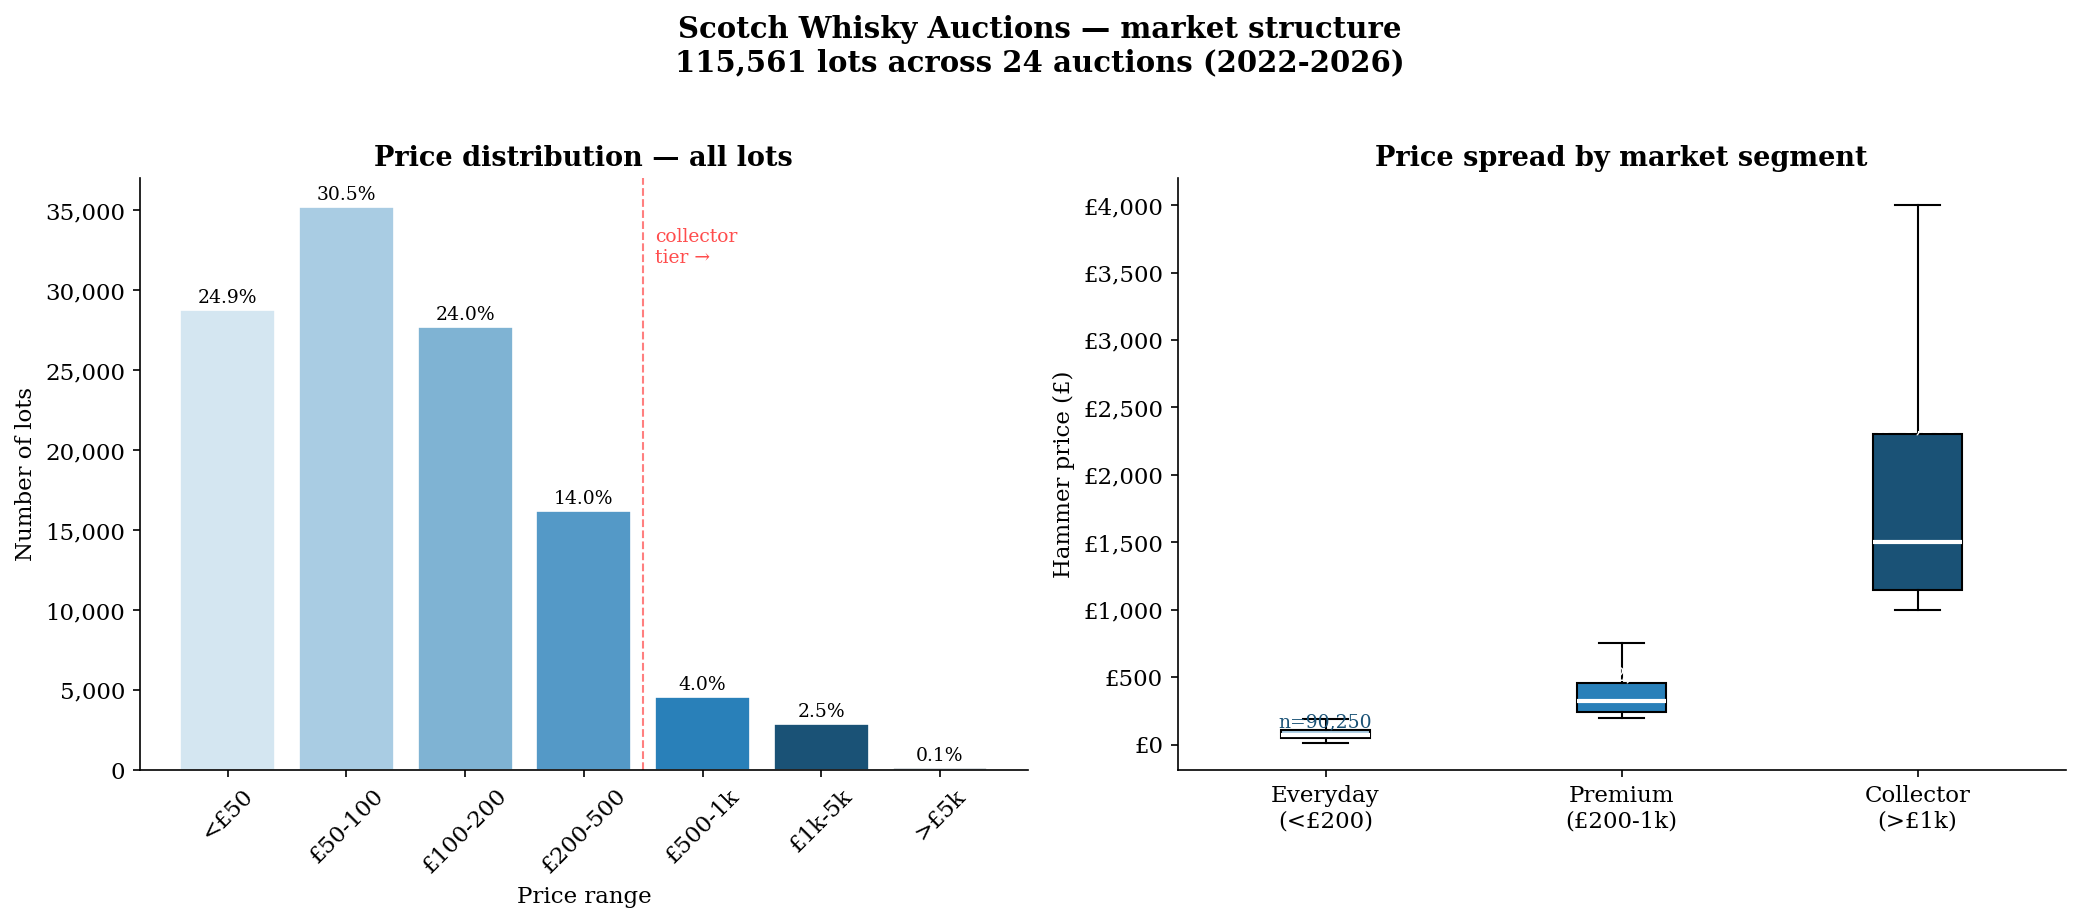

Saved viz1_market_overview.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

prices = df["winning_bid"].dropna()
bins = [0, 50, 100, 200, 500, 1000, 5000, 50000]
labels = ["<£50", "£50-100", "£100-200", 
          "£200-500", "£500-1k", "£1k-5k", ">£5k"]
counts = pd.cut(prices, bins=bins, labels=labels).value_counts()
counts = counts.reindex(labels)

colors = ["#d4e6f1", "#a9cce3", "#7fb3d3", 
          "#5499c7", "#2980b9", "#1a5276", "#0d2b3e"]

bars = axes[0].bar(labels, counts.values, color=colors, 
                   edgecolor="white", linewidth=0.8)
axes[0].set_title("Price distribution — all lots")
axes[0].set_xlabel("Price range")
axes[0].set_ylabel("Number of lots")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)
axes[0].tick_params(axis="x", rotation=45)

for bar, count in zip(bars, counts.values):
    pct = count / len(prices) * 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

axes[0].axvline(x=3.5, color="red", linestyle="--", 
                linewidth=1, alpha=0.5)
axes[0].text(3.6, counts.max() * 0.9, 
             "collector\ntier →", 
             fontsize=9, color="red", alpha=0.7)

segment_data = {
    "Everyday\n(<£200)":   df[df["winning_bid"] < 200]["winning_bid"],
    "Premium\n(£200-1k)":  df[(df["winning_bid"] >= 200) & 
                               (df["winning_bid"] < 1000)]["winning_bid"],
    "Collector\n(>£1k)":   df[df["winning_bid"] >= 1000]["winning_bid"],
}

bp = axes[1].boxplot(
    [s.values for s in segment_data.values()],
    labels=segment_data.keys(),
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="white", linewidth=2)
)

segment_colors = ["#a9cce3", "#2980b9", "#1a5276"]
for patch, color in zip(bp["boxes"], segment_colors):
    patch.set_facecolor(color)

axes[1].set_title("Price spread by market segment")
axes[1].set_ylabel("Hammer price (£)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

for i, (label, series) in enumerate(segment_data.items()):
    axes[1].text(
        i + 1, series.quantile(0.75) + 20,
        f"n={len(series):,}",
        ha="center", fontsize=9, color="white"
        if i > 0 else "#1a5276"
    )

plt.suptitle(
    "Scotch Whisky Auctions — market structure\n"
    "115,561 lots across 24 auctions (2022-2026)",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("viz1_market_overview.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz1_market_overview.png")

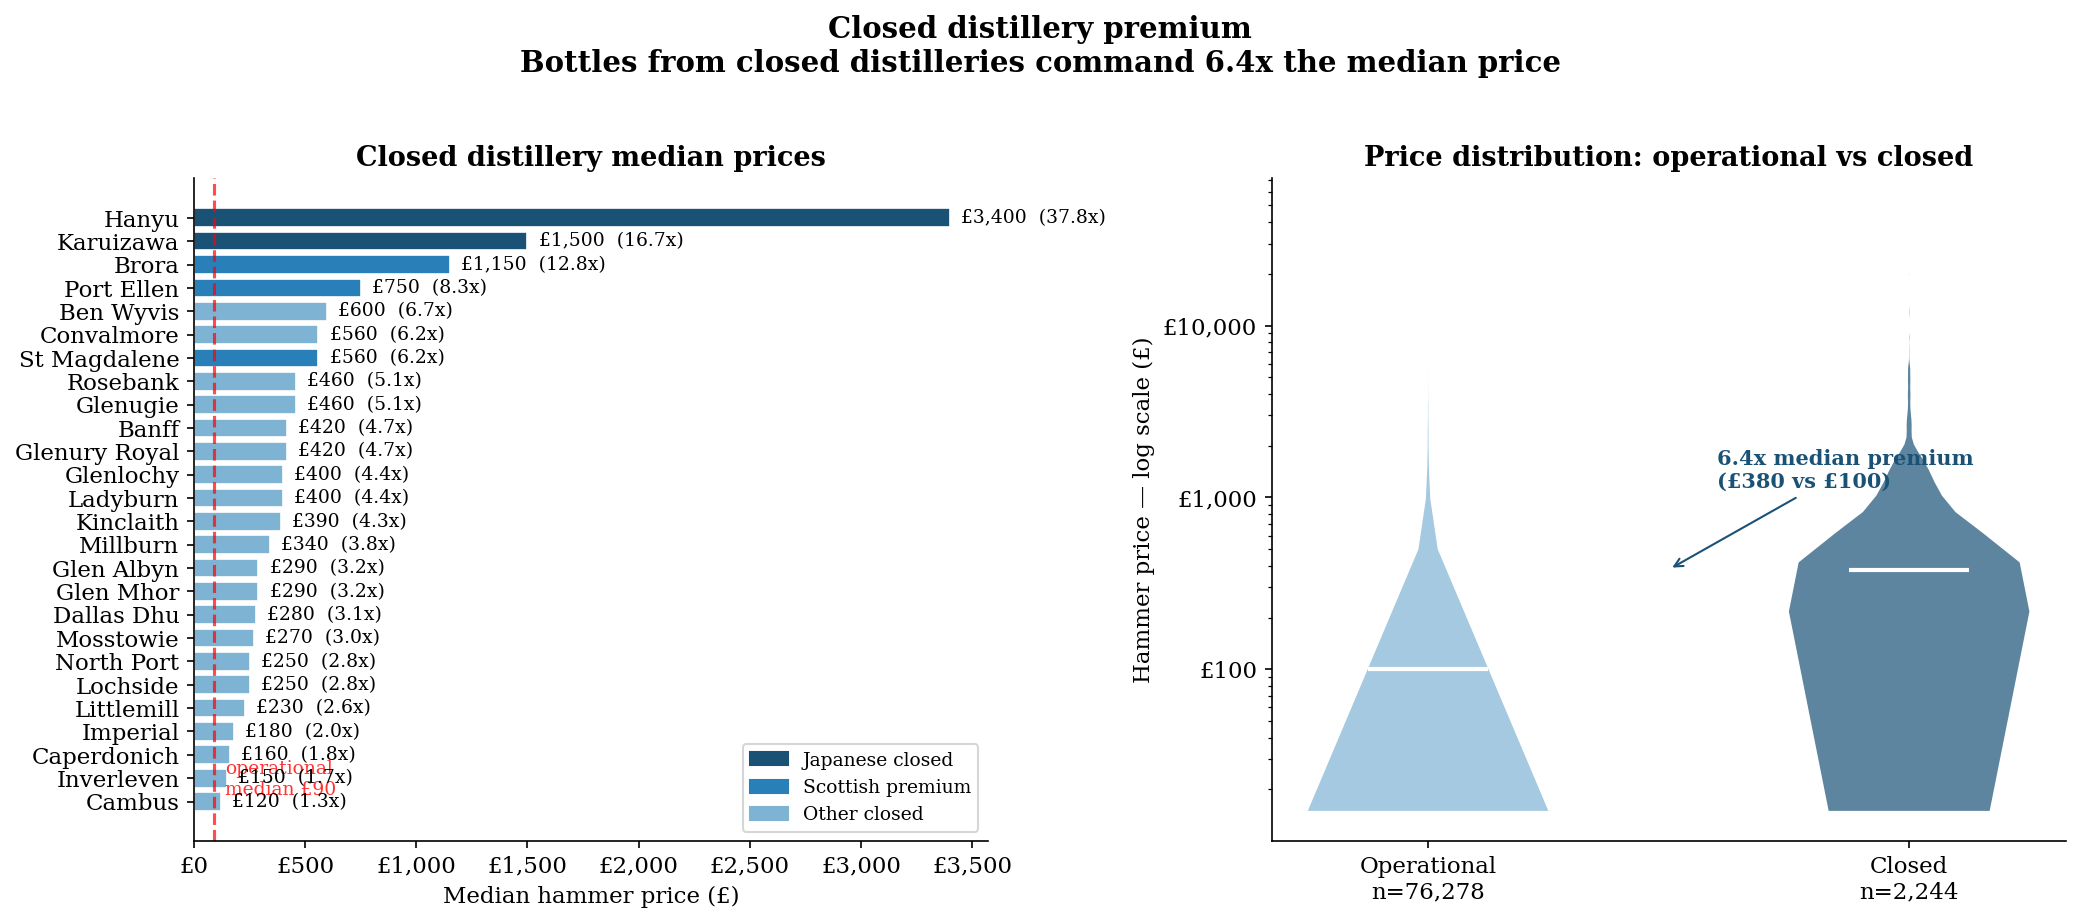

Saved viz2_closed_distillery.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

closed_data = (df[df["is_closed"] == True]
               .groupby("distillery")
               .agg(
                   lots=("winning_bid", "count"),
                   median_price=("winning_bid", "median"),
                   avg_price=("winning_bid", "mean")
               )
               .query("lots >= 5")
               .sort_values("median_price", ascending=True))

operational_median = df[
    df["is_closed"] == False
]["winning_bid"].median()

colors_closed = []
japanese = {"Karuizawa", "Hanyu", "Shirakawa"}
scottish_premium = {"Brora", "Port Ellen", "St Magdalene"}
for dist in closed_data.index:
    if dist in japanese:
        colors_closed.append("#1a5276")
    elif dist in scottish_premium:
        colors_closed.append("#2980b9")
    else:
        colors_closed.append("#7fb3d3")

bars = axes[0].barh(
    closed_data.index,
    closed_data["median_price"],
    color=colors_closed,
    edgecolor="white",
    linewidth=0.8
)

axes[0].axvline(
    x=operational_median,
    color="red", linestyle="--",
    linewidth=1.5, alpha=0.7
)
axes[0].text(
    operational_median + 50,
    0.3,
    f"operational\nmedian £{operational_median:.0f}",
    fontsize=9, color="red", alpha=0.8
)

for bar, (_, row) in zip(bars, closed_data.iterrows()):
    premium = row["median_price"] / operational_median
    axes[0].text(
        row["median_price"] + 50,
        bar.get_y() + bar.get_height()/2,
        f"£{row['median_price']:,.0f}  ({premium:.1f}x)",
        va="center", fontsize=9
    )

axes[0].set_title("Closed distillery median prices")
axes[0].set_xlabel("Median hammer price (£)")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

legend_elements = [
    plt.Rectangle((0,0),1,1, color="#1a5276", label="Japanese closed"),
    plt.Rectangle((0,0),1,1, color="#2980b9", label="Scottish premium"),
    plt.Rectangle((0,0),1,1, color="#7fb3d3", label="Other closed"),
]
axes[0].legend(handles=legend_elements, loc="lower right", fontsize=9)

operational_sample = df[
    (df["is_closed"] == False) &
    (df["distillery"].notna())
]["winning_bid"].dropna()

closed_sample = df[
    df["is_closed"] == True
]["winning_bid"].dropna()

violin_data = [operational_sample.values, closed_sample.values]
vp = axes[1].violinplot(
    violin_data,
    positions=[1, 2],
    showmedians=True,
    showextrema=False
)

for pc, color in zip(vp["bodies"], ["#7fb3d3", "#1a5276"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

vp["cmedians"].set_colors(["white", "white"])
vp["cmedians"].set_linewidth(2)

axes[1].set_yscale("log")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels([
    f"Operational\nn={len(operational_sample):,}",
    f"Closed\nn={len(closed_sample):,}"
])
axes[1].set_ylabel("Hammer price — log scale (£)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
axes[1].set_title("Price distribution: operational vs closed")

axes[1].annotate(
    f"6.4x median premium\n"
    f"(£{closed_sample.median():,.0f} vs £{operational_sample.median():,.0f})",
    xy=(1.5, closed_sample.median()),
    xytext=(1.6, closed_sample.median() * 3),
    fontsize=10, fontweight="bold",
    color="#1a5276",
    arrowprops=dict(arrowstyle="->", color="#1a5276")
)

plt.suptitle(
    "Closed distillery premium\n"
    "Bottles from closed distilleries command 6.4x the median price",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("viz2_closed_distillery.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz2_closed_distillery.png")

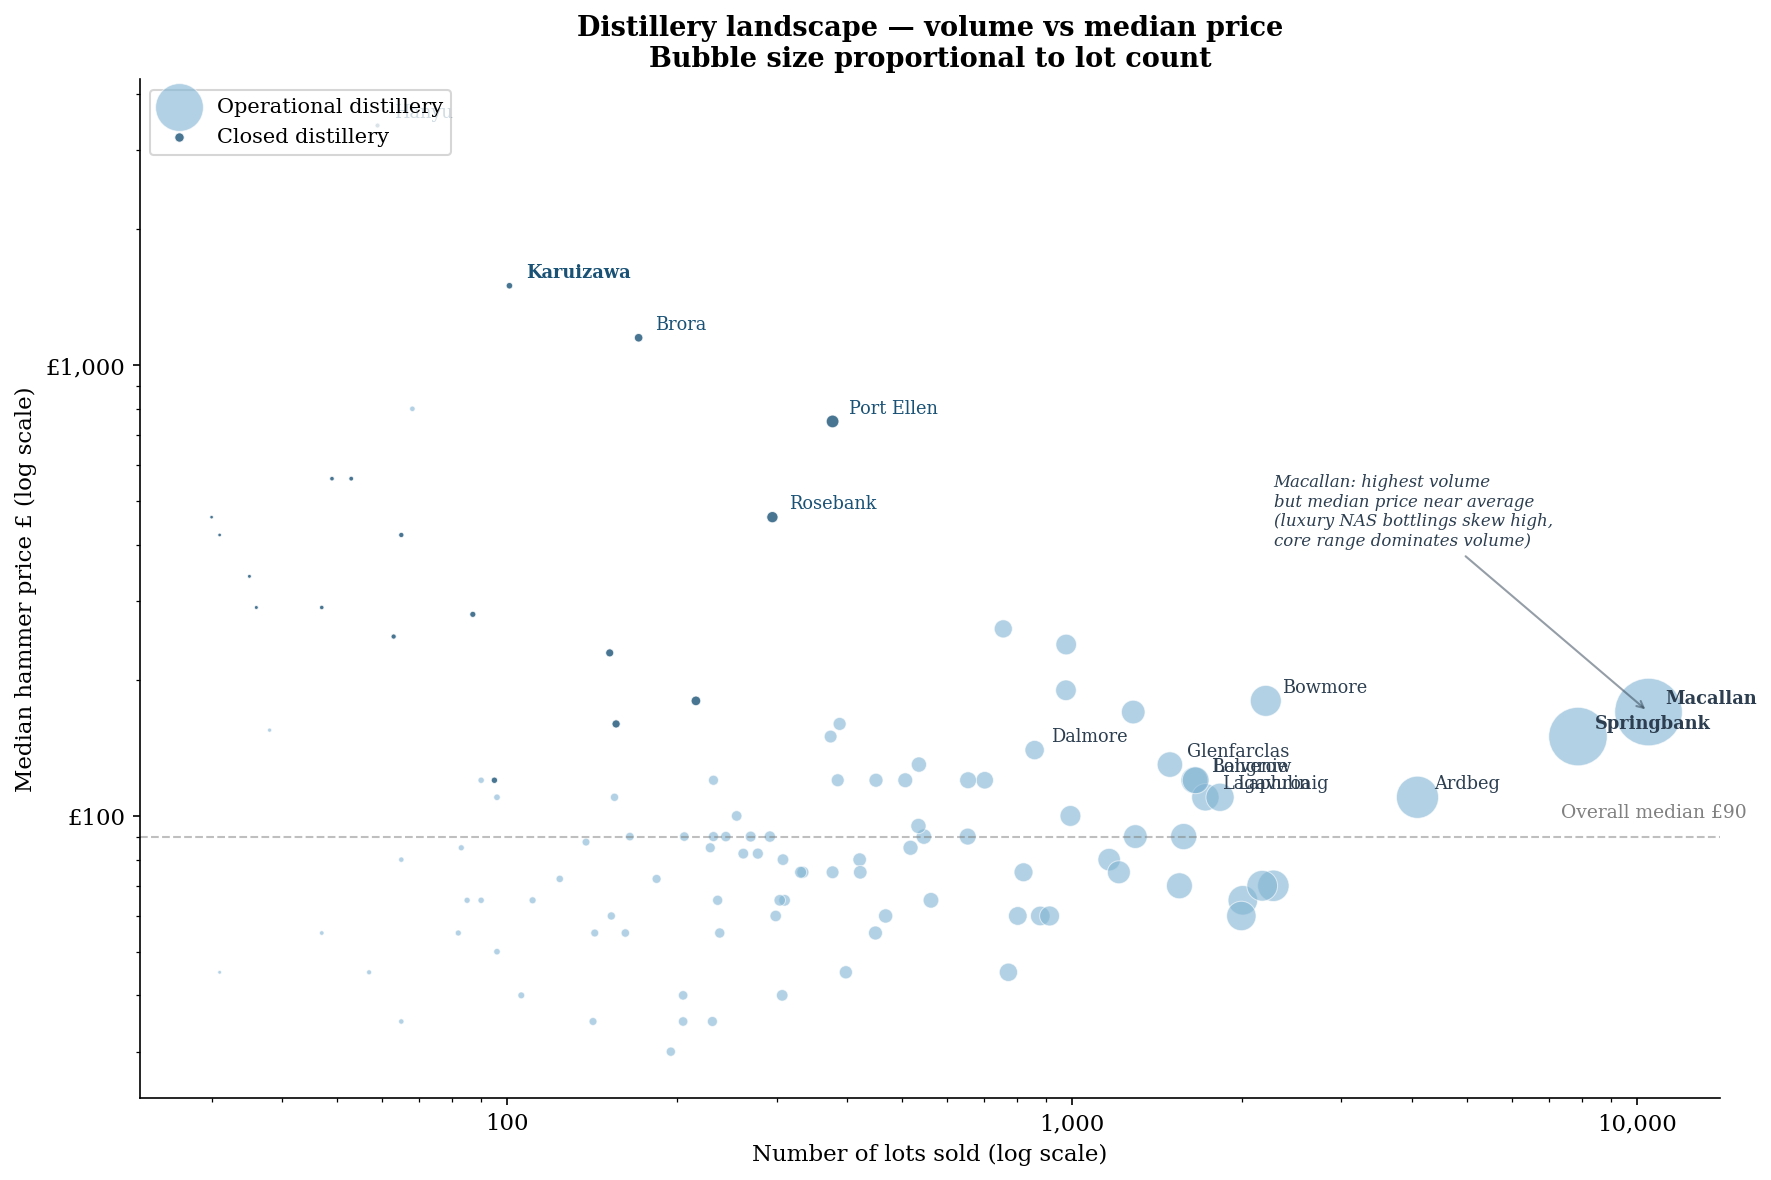

Saved viz3_distillery_landscape.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

dist_stats = (df[df["distillery"].notna()]
              .groupby("distillery")
              .agg(
                  lots=("winning_bid", "count"),
                  median_price=("winning_bid", "median"),
                  avg_price=("winning_bid", "mean"),
                  is_closed=("is_closed", "first")
              )
              .query("lots >= 30")
              .reset_index())

operational = dist_stats[dist_stats["is_closed"] == False]
closed      = dist_stats[dist_stats["is_closed"] == True]

ax.scatter(
    operational["lots"],
    operational["median_price"],
    s=operational["lots"] / 10,
    color="#7fb3d3",
    alpha=0.6,
    edgecolors="white",
    linewidth=0.5,
    label="Operational distillery",
    zorder=2
)

ax.scatter(
    closed["lots"],
    closed["median_price"],
    s=closed["lots"] / 10,
    color="#1a5276",
    alpha=0.8,
    edgecolors="white",
    linewidth=0.5,
    label="Closed distillery",
    zorder=3
)

highlight = [
    "Macallan", "Springbank", "Ardbeg",
    "Bowmore", "Port Ellen", "Karuizawa",
    "Brora", "Glenfarclas", "Laphroaig",
    "Balvenie", "Rosebank", "Hanyu",
    "Dalmore", "Lagavulin", "Longrow",
]

for _, row in dist_stats[
    dist_stats["distillery"].isin(highlight)
].iterrows():
    color = "#1a5276" if row["is_closed"] else "#2c3e50"
    ax.annotate(
        row["distillery"],
        xy=(row["lots"], row["median_price"]),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=8.5,
        color=color,
        fontweight="bold" if row["distillery"] in 
            ["Macallan", "Springbank", "Karuizawa"] 
            else "normal"
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of lots sold (log scale)", fontsize=11)
ax.set_ylabel("Median hammer price £ (log scale)", fontsize=11)
ax.set_title(
    "Distillery landscape — volume vs median price\n"
    "Bubble size proportional to lot count",
    fontsize=13, fontweight="bold"
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

ax.axhline(
    y=df["winning_bid"].median(),
    color="gray", linestyle="--",
    linewidth=1, alpha=0.5
)
ax.text(
    dist_stats["lots"].max() * 0.7,
    df["winning_bid"].median() * 1.1,
    f"Overall median £{df['winning_bid'].median():.0f}",
    fontsize=9, color="gray"
)

ax.annotate(
    "Macallan: highest volume\nbut median price near average\n(luxury NAS bottlings skew high,\ncore range dominates volume)",
    xy=(dist_stats[dist_stats["distillery"]=="Macallan"]["lots"].values[0],
        dist_stats[dist_stats["distillery"]=="Macallan"]["median_price"].values[0]),
    xytext=(-180, 80),
    textcoords="offset points",
    fontsize=8,
    color="#2c3e50",
    style="italic",
    arrowprops=dict(arrowstyle="->", color="#2c3e50", alpha=0.5)
)

ax.legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig("viz3_distillery_landscape.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz3_distillery_landscape.png")

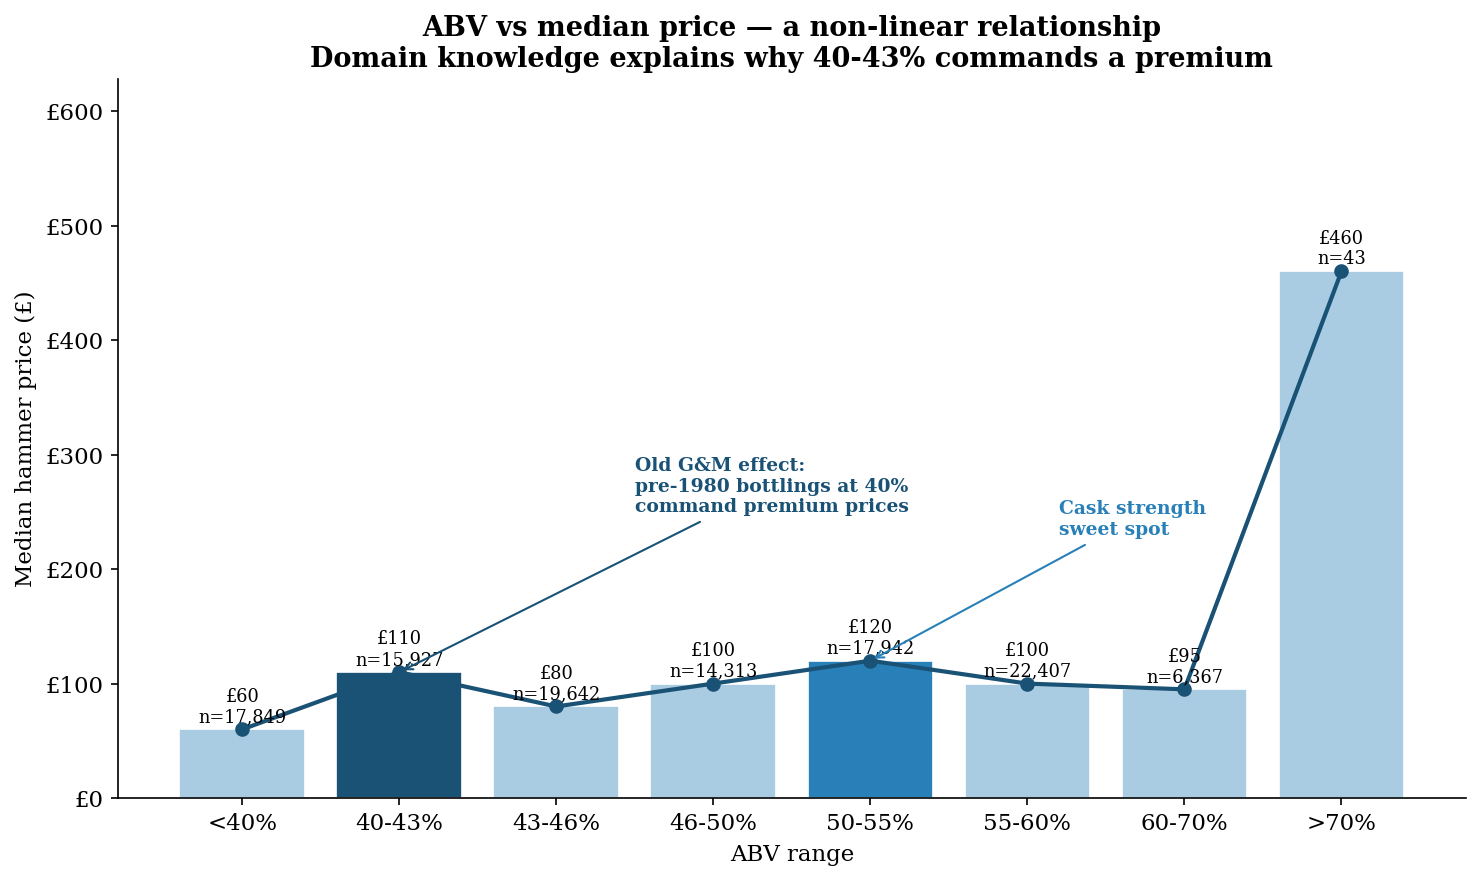

Saved viz4_abv_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

abv_bins = [0, 40, 43, 46, 50, 55, 60, 70, 100]
abv_labels = ["<40%", "40-43%", "43-46%", "46-50%",
              "50-55%", "55-60%", "60-70%", ">70%"]

df["abv_group"] = pd.cut(
    df["abv"], bins=abv_bins, labels=abv_labels
)

abv_stats = (df.groupby("abv_group", observed=True)
             .agg(
                 median_price=("winning_bid", "median"),
                 count=("winning_bid", "count"),
                 pct_over_500=("winning_bid",
                               lambda x: (x > 500).mean() * 100)
             )
             .reset_index())

colors_abv = []
for label in abv_labels:
    if label == "40-43%":
        colors_abv.append("#1a5276")
    elif label == "50-55%":
        colors_abv.append("#2980b9")
    else:
        colors_abv.append("#a9cce3")

bars = ax.bar(
    abv_stats["abv_group"],
    abv_stats["median_price"],
    color=colors_abv,
    edgecolor="white",
    linewidth=0.8,
    zorder=2
)

ax.plot(
    range(len(abv_labels)),
    abv_stats["median_price"],
    color="#1a5276",
    linewidth=2,
    marker="o",
    markersize=6,
    zorder=3
)

for i, (bar, row) in enumerate(
    zip(bars, abv_stats.itertuples())
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        f"£{row.median_price:.0f}\nn={row.count:,}",
        ha="center", va="bottom",
        fontsize=8.5
    )

ax.annotate(
    "Old G&M effect:\npre-1980 bottlings at 40%\ncommand premium prices",
    xy=(1, abv_stats[abv_stats["abv_group"]=="40-43%"]
        ["median_price"].values[0]),
    xytext=(2.5, 250),
    fontsize=9,
    color="#1a5276",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#1a5276")
)

ax.annotate(
    "Cask strength\nsweet spot",
    xy=(4, abv_stats[abv_stats["abv_group"]=="50-55%"]
        ["median_price"].values[0]),
    xytext=(5.2, 230),
    fontsize=9,
    color="#2980b9",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#2980b9")
)

ax.set_xlabel("ABV range", fontsize=11)
ax.set_ylabel("Median hammer price (£)", fontsize=11)
ax.set_title(
    "ABV vs median price — a non-linear relationship\n"
    "Domain knowledge explains why 40-43% commands a premium",
    fontsize=13, fontweight="bold"
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:.0f}")
)
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)

plt.tight_layout()
plt.savefig("viz4_abv_curve.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz4_abv_curve.png")

In [8]:
high_abv = df[df["abv"] > 70][["title", "abv", "winning_bid", "distillery"]]
print(f"Lots with ABV > 70%: {len(high_abv)}")
print(high_abv.sort_values("winning_bid", ascending=False).head(15).to_string(index=False))

Lots with ABV > 70%: 43
                                     title   abv  winning_bid distillery
 Caroni 2000 15 Year Old Single Cask #3788 70.20       1900.0        NaN
SMWS Heaven Hill 1992 13 Year Old Cask #13 72.80       1700.0        NaN
 SMWS Heaven Hill 1990 13 Year Old Cask #3 71.20       1400.0        NaN
          George T Stagg 2012 Release 75cl 71.40       1400.0        NaN
    William Larue Weller 2014 Release 75cl 70.10       1200.0     Weller
          George T Stagg 2012 Release 75cl 71.40       1200.0        NaN
          George T Stagg 2009 Release 75cl 70.70       1050.0        NaN
          George T Stagg 2012 Release 75cl 71.40       1000.0        NaN
                  George T Stagg Fall 2005 70.60       1000.0        NaN
          George T Stagg 2010 Release 75cl 71.50        950.0        NaN
          George T Stagg 2016 Release 75cl 72.05        950.0        NaN
          George T Stagg 2016 Release 75cl 72.05        950.0        NaN
    William Larue Weller 20

In [9]:
if "George T Stagg" not in KNOWN_DISTILLERIES:
    KNOWN_DISTILLERIES.append("George T Stagg")
if "Stagg" not in KNOWN_DISTILLERIES:
    KNOWN_DISTILLERIES.append("Stagg")
if "Caroni" not in KNOWN_DISTILLERIES:
    KNOWN_DISTILLERIES.append("Caroni")
if "Heaven Hill" not in KNOWN_DISTILLERIES:
    KNOWN_DISTILLERIES.append("Heaven Hill")

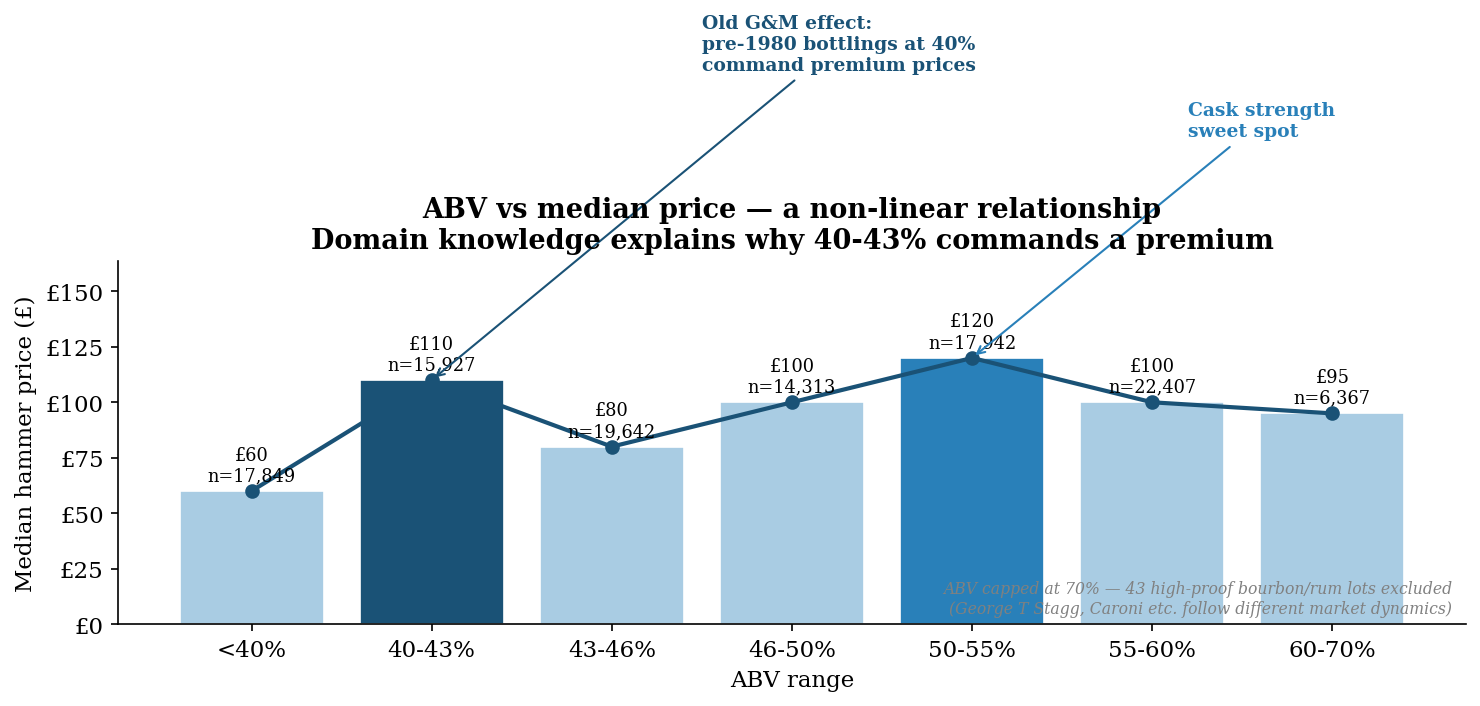

Saved viz4_abv_curve.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

abv_bins   = [0, 40, 43, 46, 50, 55, 60, 70]
abv_labels = ["<40%", "40-43%", "43-46%", "46-50%",
              "50-55%", "55-60%", "60-70%"]

df_scotch_abv = df[df["abv"] <= 70].copy()
df_scotch_abv["abv_group"] = pd.cut(
    df_scotch_abv["abv"],
    bins=abv_bins,
    labels=abv_labels
)

abv_stats = (df_scotch_abv
             .groupby("abv_group", observed=True)
             .agg(
                 median_price=("winning_bid", "median"),
                 count=("winning_bid", "count"),
             )
             .reset_index())

colors_abv = []
for label in abv_labels:
    if label == "40-43%":
        colors_abv.append("#1a5276")
    elif label == "50-55%":
        colors_abv.append("#2980b9")
    else:
        colors_abv.append("#a9cce3")

bars = ax.bar(
    abv_stats["abv_group"],
    abv_stats["median_price"],
    color=colors_abv,
    edgecolor="white",
    linewidth=0.8,
    zorder=2
)

ax.plot(
    range(len(abv_labels)),
    abv_stats["median_price"],
    color="#1a5276",
    linewidth=2,
    marker="o",
    markersize=6,
    zorder=3
)

for bar, row in zip(bars, abv_stats.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        f"£{row.median_price:.0f}\nn={row.count:,}",
        ha="center", va="bottom", fontsize=8.5
    )

ax.annotate(
    "Old G&M effect:\npre-1980 bottlings at 40%\ncommand premium prices",
    xy=(1, abv_stats[abv_stats["abv_group"]=="40-43%"]
        ["median_price"].values[0]),
    xytext=(2.5, 250),
    fontsize=9, color="#1a5276", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#1a5276")
)

ax.annotate(
    "Cask strength\nsweet spot",
    xy=(4, abv_stats[abv_stats["abv_group"]=="50-55%"]
        ["median_price"].values[0]),
    xytext=(5.2, 220),
    fontsize=9, color="#2980b9", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#2980b9")
)

ax.text(
    0.99, 0.02,
    "ABV capped at 70% — 43 high-proof bourbon/rum lots excluded\n"
    "(George T Stagg, Caroni etc. follow different market dynamics)",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=7.5, color="gray", style="italic"
)

ax.set_xlabel("ABV range", fontsize=11)
ax.set_ylabel("Median hammer price (£)", fontsize=11)
ax.set_title(
    "ABV vs median price — a non-linear relationship\n"
    "Domain knowledge explains why 40-43% commands a premium",
    fontsize=13, fontweight="bold"
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:.0f}")
)
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)

plt.tight_layout()
plt.savefig("viz4_abv_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz4_abv_curve.png")

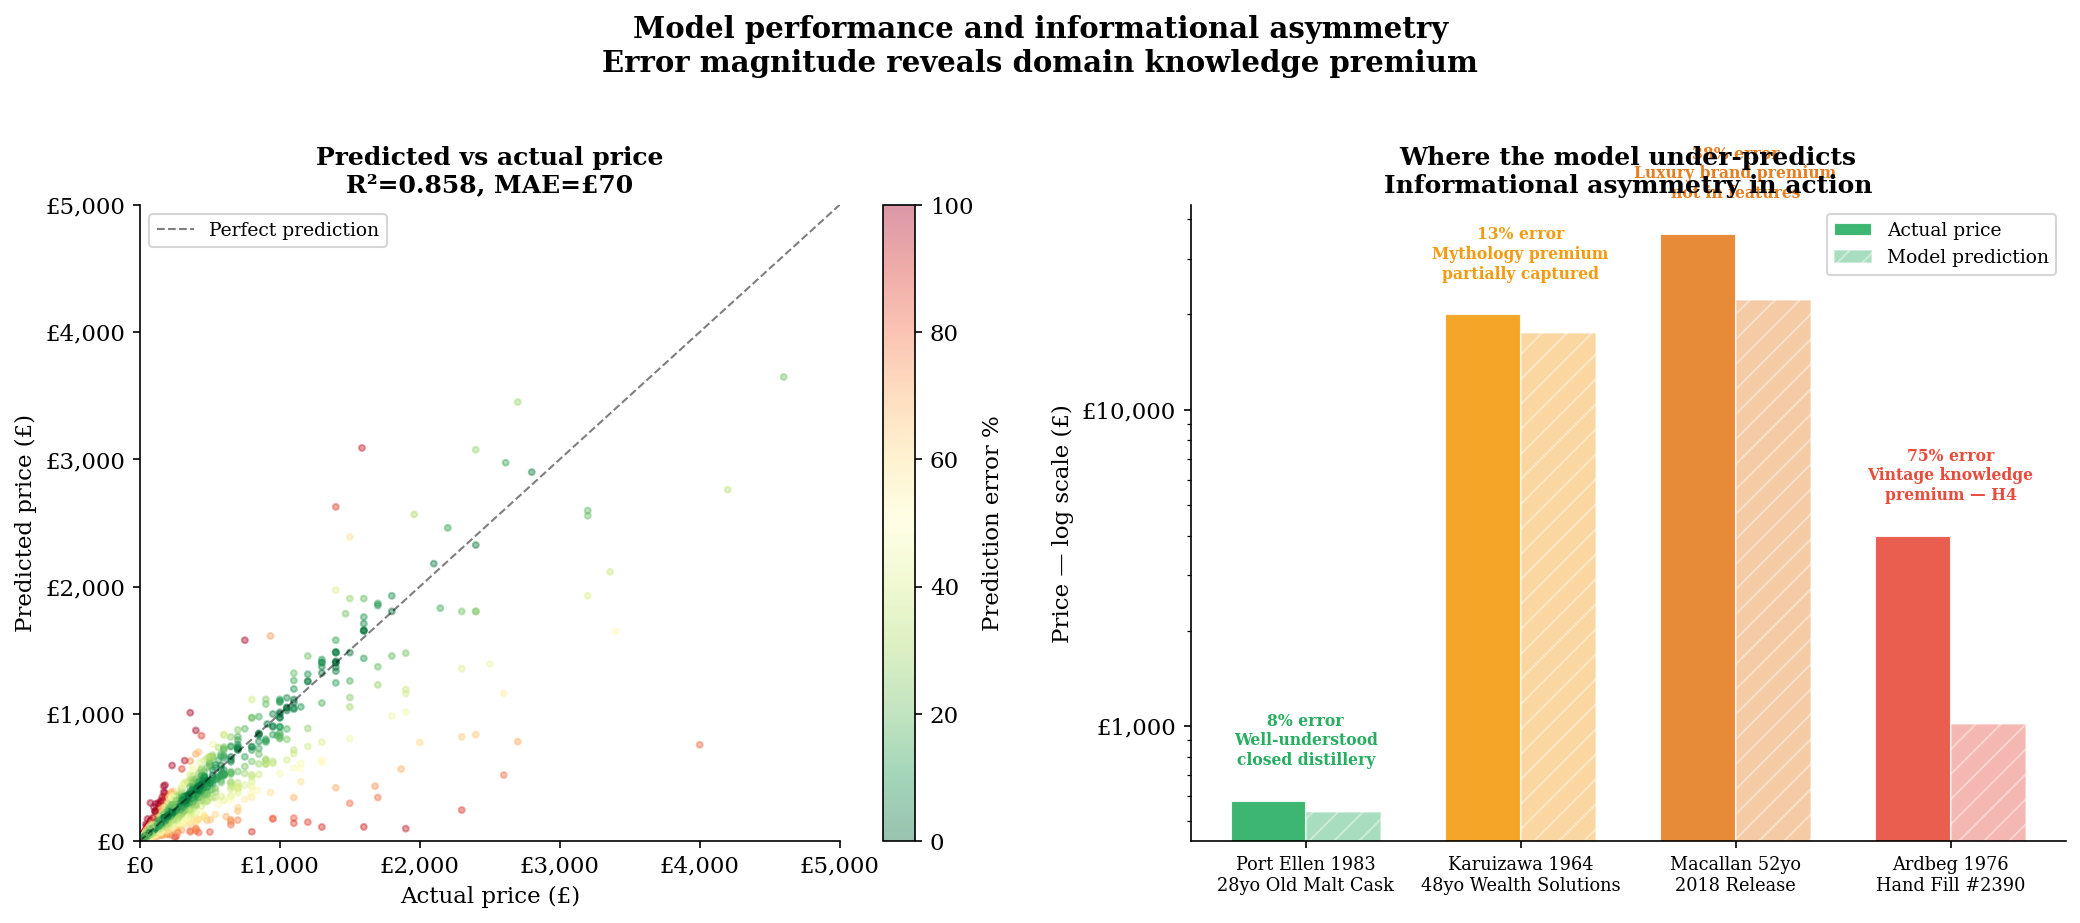

Saved viz5_model_performance.png


In [12]:
import pickle
from sklearn.preprocessing import LabelEncoder

with open("model_final.pkl", "rb") as f:
    model = pickle.load(f)

with open("label_encoders_final.pkl", "rb") as f:
    encoders = pickle.load(f)

le_dist = encoders["distillery"]
le_cask = encoders["cask"]
features = encoders["features"]

model_df = pd.read_csv("whisky_model_ready_final.csv")

model_df["predicted_price"] = np.exp(
    model.predict(model_df[features])
)
model_df["actual_price"] = np.exp(model_df["log_price"])
model_df["error_pct"] = (
    (model_df["predicted_price"] - model_df["actual_price"]) /
    model_df["actual_price"] * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = model_df.sample(3000, random_state=42)

scatter = axes[0].scatter(
    sample["actual_price"],
    sample["predicted_price"],
    c=np.abs(sample["error_pct"]),
    cmap="RdYlGn_r",
    alpha=0.4,
    s=8,
    vmin=0,
    vmax=100
)

max_price = min(sample["actual_price"].max(),
                sample["predicted_price"].max(), 5000)
axes[0].plot(
    [0, max_price], [0, max_price],
    "k--", linewidth=1, alpha=0.5, label="Perfect prediction"
)

plt.colorbar(scatter, ax=axes[0], label="Prediction error %")

axes[0].set_xlim(0, max_price)
axes[0].set_ylim(0, max_price)
axes[0].set_xlabel("Actual price (£)", fontsize=11)
axes[0].set_ylabel("Predicted price (£)", fontsize=11)
axes[0].set_title(
    f"Predicted vs actual price\nR²={0.858:.3f}, MAE=£70",
    fontsize=12, fontweight="bold"
)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
axes[0].legend(fontsize=9)

bottles = [
    {
        "name": "Port Ellen 1983\n28yo Old Malt Cask",
        "actual": 580,
        "predicted": 534,
        "explanation": "Well-understood\nclosed distillery",
        "color": "#27ae60"
    },
    {
        "name": "Karuizawa 1964\n48yo Wealth Solutions",
        "actual": 20000,
        "predicted": 17427,
        "explanation": "Mythology premium\npartially captured",
        "color": "#f39c12"
    },
    {
        "name": "Macallan 52yo\n2018 Release",
        "actual": 36000,
        "predicted": 22186,
        "explanation": "Luxury brand premium\nnot in features",
        "color": "#e67e22"
    },
    {
        "name": "Ardbeg 1976\nHand Fill #2390",
        "actual": 4000,
        "predicted": 1015,
        "explanation": "Vintage knowledge\npremium — H4",
        "color": "#e74c3c"
    },
]

x = np.arange(len(bottles))
width = 0.35

actual_vals    = [b["actual"] for b in bottles]
predicted_vals = [b["predicted"] for b in bottles]
colors_act     = [b["color"] for b in bottles]

bars_act  = axes[1].bar(
    x - width/2, actual_vals,
    width, label="Actual price",
    color=colors_act, alpha=0.9,
    edgecolor="white"
)
bars_pred = axes[1].bar(
    x + width/2, predicted_vals,
    width, label="Model prediction",
    color=colors_act, alpha=0.4,
    edgecolor="white", hatch="//"
)

axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [b["name"] for b in bottles],
    fontsize=8.5
)
axes[1].set_ylabel("Price — log scale (£)", fontsize=11)
axes[1].set_title(
    "Where the model under-predicts\nInformational asymmetry in action",
    fontsize=12, fontweight="bold"
)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
axes[1].legend(fontsize=9)

for i, bottle in enumerate(bottles):
    error = abs(bottle["actual"] - bottle["predicted"])
    pct   = error / bottle["actual"] * 100
    axes[1].text(
        i, max(bottle["actual"], bottle["predicted"]) * 1.3,
        f"{pct:.0f}% error\n{bottle['explanation']}",
        ha="center", fontsize=7.5,
        color=bottle["color"], fontweight="bold"
    )

plt.suptitle(
    "Model performance and informational asymmetry\n"
    "Error magnitude reveals domain knowledge premium",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("viz5_model_performance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz5_model_performance.png")

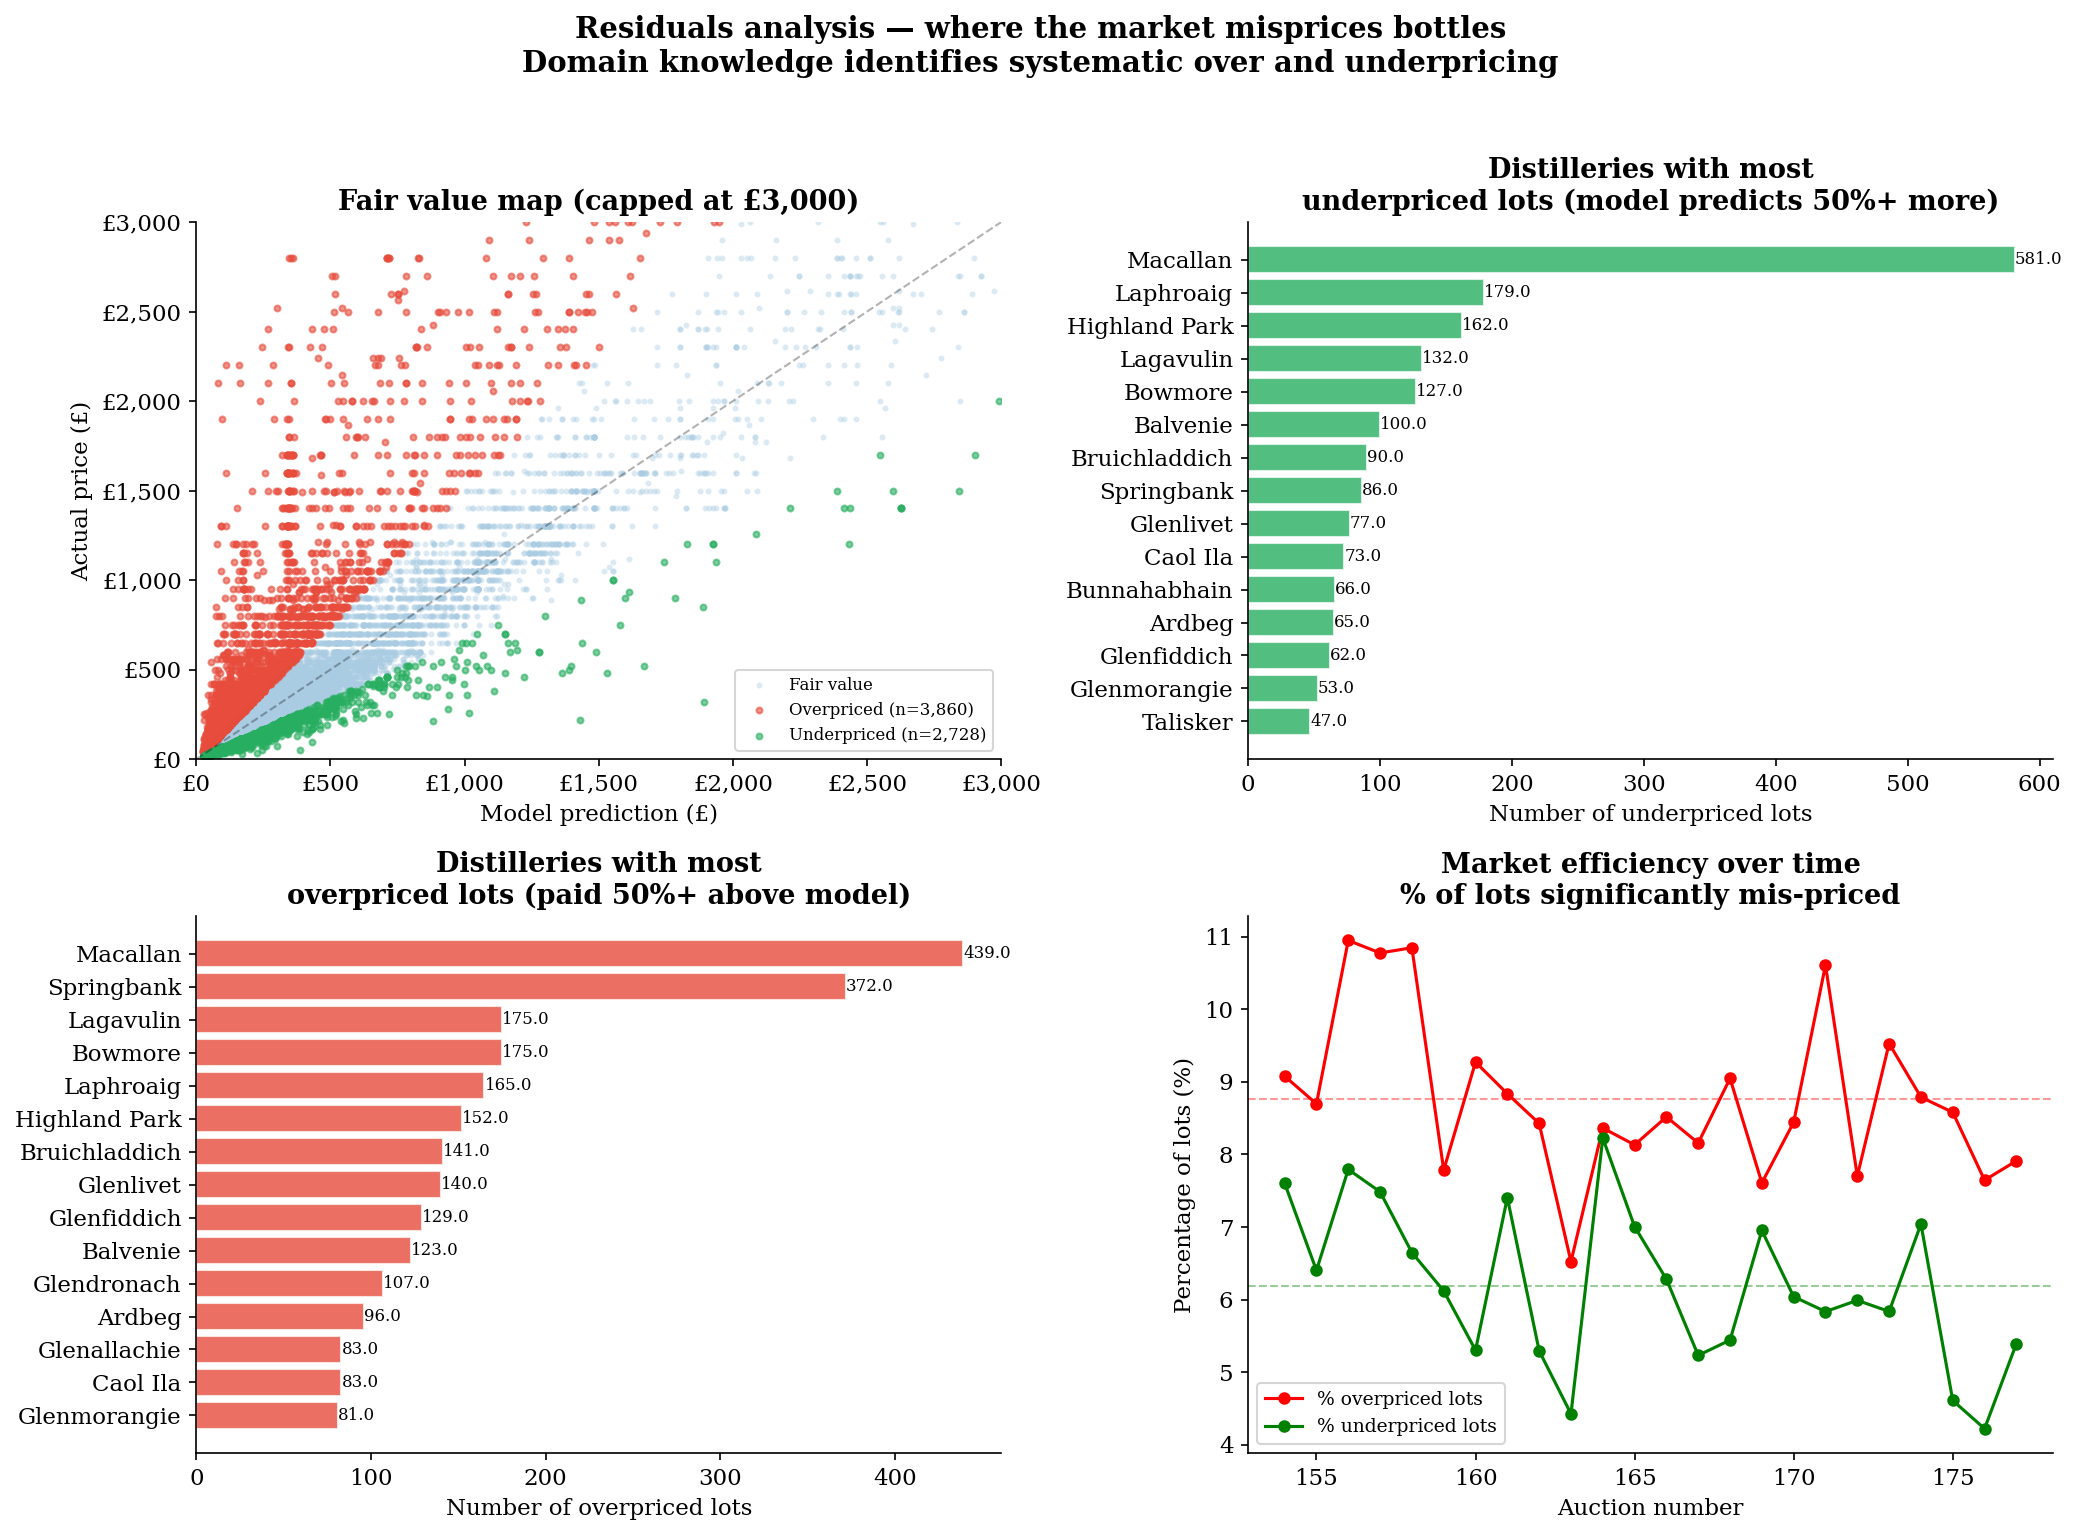

Saved viz6_residuals_map.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_df["value_ratio"] = (
    model_df["actual_price"] / model_df["predicted_price"]
)

ax = axes[0, 0]
over  = model_df[model_df["value_ratio"] > 1.5]
under = model_df[model_df["value_ratio"] < 0.67]
fair  = model_df[
    (model_df["value_ratio"] >= 0.67) &
    (model_df["value_ratio"] <= 1.5)
]

ax.scatter(
    fair["predicted_price"], fair["actual_price"],
    s=4, alpha=0.3, color="#a9cce3", label="Fair value"
)
ax.scatter(
    over["predicted_price"], over["actual_price"],
    s=8, alpha=0.6, color="#e74c3c",
    label=f"Overpriced (n={len(over):,})"
)
ax.scatter(
    under["predicted_price"], under["actual_price"],
    s=8, alpha=0.6, color="#27ae60",
    label=f"Underpriced (n={len(under):,})"
)

lim = 3000
ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.3)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Model prediction (£)")
ax.set_ylabel("Actual price (£)")
ax.set_title("Fair value map (capped at £3,000)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
ax.legend(fontsize=8)

ax = axes[0, 1]
underpriced_dist = (
    model_df[model_df["value_ratio"] < 0.67]
    .groupby("distillery")
    .agg(count=("value_ratio", "count"),
         avg_ratio=("value_ratio", "mean"))
    .query("count >= 3")
    .sort_values("count", ascending=True)
    .tail(15)
)

ax.barh(
    underpriced_dist.index,
    underpriced_dist["count"],
    color="#27ae60", alpha=0.8,
    edgecolor="white"
)
ax.set_xlabel("Number of underpriced lots")
ax.set_title("Distilleries with most\nunderpriced lots (model predicts 50%+ more)")
for i, (_, row) in enumerate(underpriced_dist.iterrows()):
    ax.text(
        row["count"] + 0.1, i,
        f"{row['count']}",
        va="center", fontsize=8
    )

ax = axes[1, 0]
overpriced_dist = (
    model_df[model_df["value_ratio"] > 1.5]
    .groupby("distillery")
    .agg(count=("value_ratio", "count"),
         avg_ratio=("value_ratio", "mean"))
    .query("count >= 3")
    .sort_values("count", ascending=True)
    .tail(15)
)

ax.barh(
    overpriced_dist.index,
    overpriced_dist["count"],
    color="#e74c3c", alpha=0.8,
    edgecolor="white"
)
ax.set_xlabel("Number of overpriced lots")
ax.set_title("Distilleries with most\noverpriced lots (paid 50%+ above model)")
for i, (_, row) in enumerate(overpriced_dist.iterrows()):
    ax.text(
        row["count"] + 0.1, i,
        f"{row['count']}",
        va="center", fontsize=8
    )

ax = axes[1, 1]
auction_efficiency = (model_df
    .groupby("auction_number")
    .agg(
        median_ratio=("value_ratio", "median"),
        pct_overpriced=("value_ratio",
                        lambda x: (x > 1.5).mean() * 100),
        pct_underpriced=("value_ratio",
                         lambda x: (x < 0.67).mean() * 100)
    )
    .reset_index()
    .sort_values("auction_number"))

ax.plot(
    auction_efficiency["auction_number"],
    auction_efficiency["pct_overpriced"],
    "r-o", markersize=5, linewidth=1.5,
    label="% overpriced lots"
)
ax.plot(
    auction_efficiency["auction_number"],
    auction_efficiency["pct_underpriced"],
    "g-o", markersize=5, linewidth=1.5,
    label="% underpriced lots"
)
ax.axhline(
    y=auction_efficiency["pct_overpriced"].mean(),
    color="red", linestyle="--", alpha=0.4, linewidth=1
)
ax.axhline(
    y=auction_efficiency["pct_underpriced"].mean(),
    color="green", linestyle="--", alpha=0.4, linewidth=1
)
ax.set_xlabel("Auction number")
ax.set_ylabel("Percentage of lots (%)")
ax.set_title("Market efficiency over time\n% of lots significantly mis-priced")
ax.legend(fontsize=9)

plt.suptitle(
    "Residuals analysis — where the market misprices bottles\n"
    "Domain knowledge identifies systematic over and underpricing",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("viz6_residuals_map.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved viz6_residuals_map.png")

### Caveat on residuals analysis

Macallan's dominance of the "underpriced" category (581 lots) reflects
model limitation rather than genuine collector opportunity. The distillery
encoding treats all Macallan as one category, but Macallan sells two
distinct products — standard retail expressions (£65-200) and luxury
collector releases (£3,000-48,000) — with completely different price
drivers. High within-distillery variance produces many apparent
"mispricings" that are actually correct prices for different product tiers.

More reliable signals: Laphroaig (179) and Highland Park (162) show
smaller within-distillery variance, so their underpriced lots are more
likely to represent genuine informational asymmetry.

Future improvement: separate Macallan luxury series from core range
using title keywords before modelling.

In [14]:
print("Visualisations completed:")
import os
for viz in ["viz1_market_overview.png",
            "viz2_closed_distillery.png",
            "viz3_distillery_landscape.png",
            "viz4_abv_curve.png",
            "viz5_model_performance.png",
            "viz6_residuals_map.png"]:
    size = os.path.getsize(viz) / 1024
    print(f"  {viz:35s}  {size:>6.1f} KB")

Visualisations completed:
  viz1_market_overview.png              119.0 KB
  viz2_closed_distillery.png            208.2 KB
  viz3_distillery_landscape.png         142.8 KB
  viz4_abv_curve.png                    119.3 KB
  viz5_model_performance.png            207.0 KB
  viz6_residuals_map.png                420.8 KB


In [3]:
test_bottlers = ["Signatory", "Gordon & MacPhail", 
                 "Douglas Laing", "Cadenhead's"]

for bottler in test_bottlers:
    subset = df[df["bottler"] == bottler]["title"]
    print(f"\n{bottler} — {len(subset)} lots")
    print("Sample titles:")
    for title in subset.sample(min(5, len(subset)), 
                               random_state=42):
        print(f"  {title[:70]}")


Signatory — 968 lots
Sample titles:
  Dallas Dhu 1981 19 Year Old Signatory
  Inchmurrin 1993 22 Year Old Signatory
  Speyside (M) 2011 13 Year Old Signatory 100º Proof Edition #27
  Caol Ila 2010 10 Year Old Signatory
  Old School Single Malt 45 Year Old Tropical Fruit Edition Signatory

Gordon & MacPhail — 986 lots
Sample titles:
  Port Ellen 1980 Gordon & Macphail 35cl
  Macallan Speymalt 1998 Gordon & Macphail
  Dallas Dhu 1982 Gordon & Macphail
  Ayrshire 1970 Rare Old Gordon & MacPhail
  Rosebank 1991 Gordon & MacPhail

Douglas Laing — 82 lots
Sample titles:
  Arran 12 Year Old Douglas Laing Premier Barrel
  Ardbeg & Glenrothes 9 Year Old Douglas Laing’s Double Barrel
  Macallan & Laphroaig 10 Year Old Douglas Laing’s Double Barrel
  Caol Ila 2008 12 Year Old Douglas Laing Rangers Football Club Single C
  Macallan 20 Year Old Douglas Laing’s Private Stock Specialist Edition 

Cadenhead's — 920 lots
Sample titles:
  Royal Brackla 2010 13 Year Old Cadenhead's
  Kilkerran 2015 8 Ye

In [4]:
bottler_series_check = {
    "Signatory":        ["cask strength", "un-chillfiltered", 
                         "dumpy", "straight sided", "100 proof",
                         "100º proof", "vintage"],
    "Gordon & MacPhail":["connoisseurs choice", "connoisseur's choice",
                         "rare old", "speymalt", "generations",
                         "private collection", "mr george",
                         "distillery label"],
    "Douglas Laing":    ["old & rare", "old particular", 
                         "premier barrel", "double barrel",
                         "private stock", "remarkable regional",
                         "single minded"],
    "Cadenhead's":      ["authentic collection", "small batch",
                         "world whiskies", "green label",
                         "dumpy", "straight sided"],
}

print("Series keyword frequency in lot titles:\n")
for bottler, keywords in bottler_series_check.items():
    subset = df[df["bottler"] == bottler]["title"].str.lower()
    print(f"{bottler} ({len(subset)} lots):")
    for kw in keywords:
        count = subset.str.contains(kw, na=False).sum()
        if count > 0:
            pct = count / len(subset) * 100
            print(f"  '{kw}':  {count} lots ({pct:.1f}%)")
    print()


Series keyword frequency in lot titles:

Signatory (968 lots):
  'un-chillfiltered':  2 lots (0.2%)
  '100 proof':  5 lots (0.5%)
  '100º proof':  187 lots (19.3%)
  'vintage':  22 lots (2.3%)

Gordon & MacPhail (986 lots):
  'rare old':  60 lots (6.1%)
  'speymalt':  247 lots (25.1%)
  'generations':  1 lots (0.1%)
  'private collection':  52 lots (5.3%)
  'mr george':  4 lots (0.4%)

Douglas Laing (82 lots):
  'old particular':  6 lots (7.3%)
  'premier barrel':  21 lots (25.6%)
  'double barrel':  5 lots (6.1%)
  'private stock':  15 lots (18.3%)
  'remarkable regional':  3 lots (3.7%)

Cadenhead's (920 lots):
  'authentic collection':  1 lots (0.1%)



In [5]:
cadenhead_titles = df[df["bottler"] == "Cadenhead's"]["title"].str.lower()

cadenhead_words = {}
for title in cadenhead_titles:
    words = title.replace("cadenhead's", "").replace("cadenheads", "").strip()
    for phrase in ["green label", "dumpy", "straight", "authentic", 
                   "small batch", "original collection", "chairman's stock",
                   "chairmans stock", "world whiskies", "single cask",
                   "cask strength", "distillery edition", "warehouse tasting",
                   "bond", "aged", "millennium"]:
        if phrase in words:
            cadenhead_words[phrase] = cadenhead_words.get(phrase, 0) + 1

print("Cadenhead keyword hits:")
for kw, count in sorted(cadenhead_words.items(), 
                         key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  '{kw}':  {count} lots")

print("\n\nRandom sample of 30 Cadenhead titles:")
sample_titles = df[df["bottler"] == "Cadenhead's"]["title"].sample(
    30, random_state=42
)
for title in sample_titles:
    print(f"  {title[:80]}")
    

Cadenhead keyword hits:
  'warehouse tasting':  73 lots
  'bond':  1 lots
  'authentic':  1 lots
  'original collection':  1 lots


Random sample of 30 Cadenhead titles:
  Royal Brackla 2010 13 Year Old Cadenhead's
  Kilkerran 2015 8 Year Old Cadenhead's
  Kyrö 2017 6 Year Old Cadenhead's
  Loch Lomond (Inchmurrin) 1996 19 Year Old Cadenhead's
  Hazelburn 13 Year Old Cadenhead's
  Invergordon 2007 16 Year Old Cadenhead's
  Macallan-Glenlivet 1987 17 Year Old Cadenhead's
  Inchgower 2009 13 Year Old Cadenhead's
  Blended Malt 12 Year Old Cadenhead's Warehouse Tasting
  An Orkney 2009 12 Year Old Cadenhead's Warehouse Tasting
  Strathclyde 1989 32 Year Old Cadenhead's
  Glentauchers-Glenlivet 1990 26 Year Old Cadenhead's
  Ardbeg 17 Year Old Cadenhead's 75cl
  Ardbeg 1993 19 Year Old Cadenhead's
  Blended Scotch 25 Year Old For Cadenhead's Whisky Shop Edinburgh
  Caledonian 1987 30 Year Old Cadenhead's Cask Ends
  Tullibardine 2012 11 Year Old Cadenhead's
  Balblair 2013 10 Year Old Cade

In [6]:
cadenhead_lots = df[df["bottler"] == "Cadenhead's"]["title"]

cadenhead_series_check = {
    "dumpy":             ["dumpy"],
    "tall":              ["tall bottle", "straight sided", 
                          "tall 1960"],
    "150th anniversary": ["150th", "150 th", "150th anniversary"],
    "175th anniversary": ["175th", "175th anniversary"],
    "authentic collection": ["authentic collection"],
    "chairman's stock":  ["chairman's stock", "chairmans stock",
                          "chairman stock"],
    "small batch":       ["small batch"],
    "warehouse tasting": ["warehouse tasting"],
    "original collection": ["original collection"],
    "world whiskies":    ["world whisk"],
    "enigma":            ["enigma"],
    "cask ends":         ["cask ends"],
    "campbeltown malts": ["campbeltown malts festival",
                          "campbeltown malt festival"],
    "single cask":       ["single cask"],
}

print(f"Cadenhead's series detection ({len(cadenhead_lots)} lots):\n")
for series, keywords in cadenhead_series_check.items():
    count = cadenhead_lots.str.lower().apply(
        lambda t: any(kw in t for kw in keywords)
        if pd.notna(t) else False
    ).sum()
    if count > 0:
        pct = count / len(cadenhead_lots) * 100
        print(f"  {series:25s}  {count:>4} lots  ({pct:.1f}%)")

print(f"\n  {'unclassified':25s}  "
      f"{len(cadenhead_lots):>4} total")

Cadenhead's series detection (920 lots):

  175th anniversary             2 lots  (0.2%)
  authentic collection          1 lots  (0.1%)
  warehouse tasting            73 lots  (7.9%)
  original collection           1 lots  (0.1%)
  enigma                       54 lots  (5.9%)
  cask ends                     9 lots  (1.0%)
  campbeltown malts            17 lots  (1.8%)

  unclassified                920 total


In [7]:
def detect_cadenhead_series(title, bottler, abv, 
                             bottling_year, distillation_year):
    if bottler not in ["Cadenhead's", "Cadenhead", "Cadenheads"]:
        return "non-cadenhead", 1
    
    title_lower = str(title).lower() if title else ""
    
    if any(kw in title_lower for kw in 
           ["dumpy", "brown dumpy"]):
        return "dumpy", 5
    
    if (abv and bottling_year and 
        abv in [45.7, 46.0] and 
        bottling_year <= 1991):
        return "dumpy (inferred)", 5
    
    if (abv and bottling_year and
        abv in [45.7, 46.0] and
        bottling_year < 1977):
        return "tall (inferred)", 5
    
    if any(kw in title_lower for kw in 
           ["150th anniversary", "150th"]):
        return "150th anniversary", 4
    
    if any(kw in title_lower for kw in
           ["175th anniversary", "175th"]):
        return "175th anniversary", 4
    
    if any(kw in title_lower for kw in
           ["authentic collection"]):
        return "authentic collection", 4
    
    if any(kw in title_lower for kw in
           ["chairman's stock", "chairmans stock"]):
        return "chairmans stock", 3
    
    if any(kw in title_lower for kw in
           ["warehouse tasting"]):
        return "warehouse tasting", 3
    
    if any(kw in title_lower for kw in
           ["campbeltown malts festival",
            "campbeltown malt festival"]):
        return "campbeltown malts", 3
    
    if any(kw in title_lower for kw in ["enigma"]):
        return "enigma", 2
    
    if any(kw in title_lower for kw in ["small batch"]):
        return "small batch", 2
    
    if any(kw in title_lower for kw in ["cask ends"]):
        return "cask ends", 2
    
    if any(kw in title_lower for kw in
           ["world whisk"]):
        return "world whiskies", 2
    
    if any(kw in title_lower for kw in
           ["original collection"]):
        return "original collection", 2
    
    return "standard", 1


In [8]:
cadenhead_df = df[
    df["bottler"].isin(["Cadenhead's", "Cadenhead", "Cadenheads"])
].copy()

cadenhead_df[["series", "series_tier"]] = cadenhead_df.apply(
    lambda r: pd.Series(detect_cadenhead_series(
        r["title"], r["bottler"], r["abv"],
        r["bottling_year"], r["distillation_year"]
    )), axis=1
)

print("Cadenhead series classification:")
print(cadenhead_df.groupby("series").agg(
    lots=("winning_bid", "count"),
    median_price=("winning_bid", "median"),
    tier=("series_tier", "first")
).sort_values("tier", ascending=False).to_string())

Cadenhead series classification:
                      lots  median_price  tier
series                                        
dumpy (inferred)        13         950.0     5
150th anniversary        2         260.0     4
authentic collection     7         200.0     4
175th anniversary        2         700.0     4
campbeltown malts       88          65.0     3
chairmans stock          1          70.0     3
warehouse tasting      185          60.0     3
cask ends               22         195.0     2
enigma                 236          65.0     2
original collection      1          80.0     2
small batch              1          40.0     2
standard              2939          65.0     1


In [9]:
print("Cadenhead lots with bottling year known:")
print(f"  Total: {cadenhead_df['bottling_year'].notna().sum()}")

print("\nABV distribution for Cadenhead lots:")
print(cadenhead_df["abv"].value_counts().head(20))

print("\nBottling year distribution:")
print(cadenhead_df["bottling_year"].value_counts()
      .sort_index().head(30).to_string())

Cadenhead lots with bottling year known:
  Total: 2782

ABV distribution for Cadenhead lots:
abv
46.0    368
55.0     91
53.2     79
54.8     64
55.8     63
54.7     54
51.8     51
54.9     49
56.8     48
48.2     46
51.6     45
53.7     44
58.0     43
52.9     43
54.4     41
57.5     40
52.2     40
56.2     37
40.2     37
53.6     35
Name: count, dtype: int64

Bottling year distribution:
bottling_year
1977.0     2
1979.0     3
1980.0     2
1982.0     1
1983.0     1
1984.0     2
1985.0     5
1988.0     1
1989.0     1
1990.0     4
1991.0     3
1992.0     4
1993.0     3
1994.0     2
1995.0     3
1996.0     6
1997.0     7
1998.0     9
1999.0     2
2000.0     7
2001.0     4
2002.0     9
2003.0     5
2004.0     4
2005.0    11
2006.0     4
2007.0     8
2008.0     4
2009.0     1
2010.0     7


In [10]:
print("Early Cadenhead bottles (pre-1992) with known bottling year:")
early = cadenhead_df[
    cadenhead_df["bottling_year"].notna() &
    (cadenhead_df["bottling_year"] <= 1992)
][["title", "abv", "bottling_year", 
   "distillation_year", "winning_bid", "series"]].sort_values("bottling_year")

print(early.to_string(index=False))

print(f"\n\nABV 46% lots by bottling era:")
abv46 = cadenhead_df[cadenhead_df["abv"] == 46.0].copy()
bins = [1970, 1977, 1991, 1996, 2010, 2030]
labels = ["pre-dumpy", "dumpy era", "early authentic", 
          "late authentic", "modern"]
abv46["era"] = pd.cut(
    abv46["bottling_year"].fillna(0),
    bins=bins, labels=labels
)
print(abv46.groupby("era", observed=True).agg(
    lots=("winning_bid", "count"),
    median_price=("winning_bid", "median")
).to_string())

Early Cadenhead bottles (pre-1992) with known bottling year:
                                                                          title  abv  bottling_year  distillation_year  winning_bid               series
                         Caperdonich 1965 12  Year Old Cadenhead’s 26 2/3 Fl Oz  NaN         1977.0             1965.0       1100.0             standard
                                           Macduff 1964 13 Year Old Cadenhead’s  NaN         1977.0             1964.0        340.0             standard
                          Fettercairn 1957 21 Year Old Cadenhead’s 26 2/3 Fl Oz  NaN         1979.0             1957.0        950.0             standard
                           Springbank 1954 25 Year Old Cadenhead’s 26 2/3 Fl Oz  NaN         1979.0             1954.0       2900.0             standard
                           Dalwhinnie 1957 22 Year Old Cadenhead’s 26 2/3 Fl Oz 40.0         1979.0             1957.0        900.0             standard
                     

In [11]:
print("Early Cadenhead bottles (pre-1992) with known bottling year:")
early = cadenhead_df[
    cadenhead_df["bottling_year"].notna() &
    (cadenhead_df["bottling_year"] <= 1992)
][["title", "abv", "bottling_year", 
   "distillation_year", "winning_bid", "series"]].sort_values("bottling_year")

print(early.to_string(index=False))

print(f"\n\nABV 46% lots by bottling era:")
abv46 = cadenhead_df[cadenhead_df["abv"] == 46.0].copy()
bins = [1970, 1977, 1991, 1996, 2010, 2030]
labels = ["pre-dumpy", "dumpy era", "early authentic", 
          "late authentic", "modern"]
abv46["era"] = pd.cut(
    abv46["bottling_year"].fillna(0),
    bins=bins, labels=labels
)
print(abv46.groupby("era", observed=True).agg(
    lots=("winning_bid", "count"),
    median_price=("winning_bid", "median")
).to_string())

Early Cadenhead bottles (pre-1992) with known bottling year:
                                                                          title  abv  bottling_year  distillation_year  winning_bid               series
                         Caperdonich 1965 12  Year Old Cadenhead’s 26 2/3 Fl Oz  NaN         1977.0             1965.0       1100.0             standard
                                           Macduff 1964 13 Year Old Cadenhead’s  NaN         1977.0             1964.0        340.0             standard
                          Fettercairn 1957 21 Year Old Cadenhead’s 26 2/3 Fl Oz  NaN         1979.0             1957.0        950.0             standard
                           Springbank 1954 25 Year Old Cadenhead’s 26 2/3 Fl Oz  NaN         1979.0             1954.0       2900.0             standard
                           Dalwhinnie 1957 22 Year Old Cadenhead’s 26 2/3 Fl Oz 40.0         1979.0             1957.0        900.0             standard
                     

In [13]:
from whisky_utils import *

test_cases = [
    ("Highland Park 1957 23 Year Old Cadenhead's 75cl",
     "Cadenhead's", 46.0, 1980),
    ("Springbank 1954 25 Year Old Cadenhead's 26 2/3 Fl Oz",
     "Cadenhead's", None, 1979),
    ("Blended Malt 12 Year Old Cadenhead's Warehouse Tasting",
     "Cadenhead's", 55.0, 2019),
    ("Ardbeg 1993 Signatory Cask Strength Collection",
     "Signatory", 58.4, 2008),
    ("Macallan Speymalt 1998 Gordon & MacPhail",
     "Gordon & MacPhail", 40.0, 2010),
    ("Port Ellen 1983 Douglas Laing Old & Rare",
     "Douglas Laing", 52.1, 2011),
    ("Caol Ila 2010 10 Year Old Signatory",
     "Signatory", 46.0, 2020),
]

print(f"{'Title':55s}  {'Series':25s}  {'Tier'}")
print("-" * 90)
for title, bottler, abv, bot_year in test_cases:
    series, tier = detect_bottler_series(
        title, bottler, abv, bot_year
    )
    print(f"{title[:55]:55s}  "
          f"{(series or 'none'):25s}  {tier}")

Title                                                    Series                     Tier
------------------------------------------------------------------------------------------
Highland Park 1957 23 Year Old Cadenhead's 75cl          dumpy (inferred)           5
Springbank 1954 25 Year Old Cadenhead's 26 2/3 Fl Oz     standard                   1
Blended Malt 12 Year Old Cadenhead's Warehouse Tasting   warehouse tasting          3
Ardbeg 1993 Signatory Cask Strength Collection           cask strength collection   4
Macallan Speymalt 1998 Gordon & MacPhail                 speymalt                   3
Port Ellen 1983 Douglas Laing Old & Rare                 old & rare                 5
Caol Ila 2010 10 Year Old Signatory                      standard                   1


In [14]:
df[["bottler_series", "series_tier"]] = df.apply(
    lambda r: pd.Series(detect_bottler_series(
        r["title"], r["bottler"],
        r["abv"], r["bottling_year"]
    )), axis=1
)

classified = df[df["bottler_series"].notna()]
print(f"Lots with series identified: {len(classified):,} "
      f"({len(classified)/len(df)*100:.1f}%)")

print("\nSeries price hierarchy:")
series_stats = (classified
    .groupby(["bottler", "bottler_series", "series_tier"])
    .agg(
        lots=("winning_bid", "count"),
        median_price=("winning_bid", "median")
    )
    .query("lots >= 3")
    .sort_values(["bottler", "series_tier"], 
                 ascending=[True, False])
    .round(0))

print(series_stats.to_string())

Lots with series identified: 5,533 (4.8%)

Series price hierarchy:
                                                    lots  median_price
bottler           bottler_series       series_tier                    
Cadenhead         dumpy (inferred)     5.0             8         775.0
                  authentic collection 4.0             6         200.0
                  campbeltown malts    3.0            71          60.0
                  warehouse tasting    3.0           112          60.0
                  cask ends            2.0            13         230.0
                  enigma               2.0           183          65.0
                  standard             1.0          2163          65.0
Cadenhead's       dumpy (inferred)     5.0             5         950.0
                  campbeltown malts    3.0            17         100.0
                  warehouse tasting    3.0            73          60.0
                  cask ends            2.0             9         190.0
          

In [3]:
import importlib
import whisky_utils
importlib.reload(whisky_utils)
from whisky_utils import *
print("Reloaded successfully")

Reloaded successfully


In [25]:
from whisky_utils import *

test_cases = [
    ("Ardbeg 1967 Signatory Vintage 75cl",
     "Signatory", 57.9, 1991, 75),
    ("Caol Ila 2010 10 Year Old Signatory",
     "Signatory", 46.0, 2020, 70),
    ("Laphroaig 1993 Signatory Cask Strength Collection",
     "Signatory", 58.4, 2008, 70),
    ("Springbank 2015 Signatory Un-Chillfiltered Collection",
     "Signatory", 46.0, 2024, 70),
    ("Benrinnes 2016 9 Year Old Signatory 100 Proof Edition",
     "Signatory", 57.1, 2025, 70),
]

print(f"{'Title':55s}  {'Series':30s}  {'Tier'}")
print("-" * 95)
for title, bottler, abv, bot_year, vol in test_cases:
    series, tier = detect_bottler_series(
        title, bottler, abv, bot_year, vol
    )
    print(f"{title[:55]:55s}  "
          f"{(series or 'none'):30s}  {tier}")

Title                                                    Series                          Tier
-----------------------------------------------------------------------------------------------
Ardbeg 1967 Signatory Vintage 75cl                       ink pot / early (75cl)          5
Caol Ila 2010 10 Year Old Signatory                      un-chillfiltered (inferred)     3
Laphroaig 1993 Signatory Cask Strength Collection        cask strength collection        4
Springbank 2015 Signatory Un-Chillfiltered Collection    un-chillfiltered collection     3
Benrinnes 2016 9 Year Old Signatory 100 Proof Edition    100 proof                       2


In [26]:
df[["bottler_series", "series_tier"]] = df.apply(
    lambda r: pd.Series(detect_bottler_series(
        r["title"], r["bottler"],
        r["abv"], r["bottling_year"],
        r["volume_cl"]
    )), axis=1
)

signatory = df[
    df["bottler"].isin(["Signatory", "Signatory Vintage"]) &
    df["bottler_series"].notna()
].groupby(["bottler_series", "series_tier"]).agg(
    lots=("winning_bid", "count"),
    median_price=("winning_bid", "median")
).sort_values("series_tier", ascending=False).round(0)

print("Signatory series price hierarchy:")
print(signatory.to_string())

Signatory series price hierarchy:
                                         lots  median_price
bottler_series              series_tier                    
ink pot / early (75cl)      5.0             5         400.0
ink pot / early             4.0            35          65.0
silent stills               4.0             6         380.0
rare reserve                4.0             4         950.0
un-chillfiltered collection 3.0             2         308.0
early cask strength         3.0            30         410.0
un-chillfiltered (inferred) 3.0           121          65.0
symingtons choice           3.0            12         125.0
100 proof                   2.0           192          55.0
small batch                 2.0            41          60.0
vintage collection          2.0            93         110.0
standard                    1.0           427         140.0


In [20]:
early_sig = df[
    df["bottler"].isin(["Signatory", "Signatory Vintage"]) &
    df["bottling_year"].notna() &
    (df["bottling_year"] <= 1995)
][["title", "abv", "volume_cl", "bottling_year", 
   "winning_bid", "bottler_series"]].sort_values("bottling_year")

print(f"Early Signatory lots (pre-1996): {len(early_sig)}")
print(early_sig.to_string(index=False))

Early Signatory lots (pre-1996): 40
                                              title  abv  volume_cl  bottling_year  winning_bid              bottler_series
                Rosebank 1974 17 Year Old Signatory 43.0       70.0         1982.0        300.0          vintage collection
        Caperdonich 1972 16 Year Old Signatory 75cl 40.0       75.0         1988.0        400.0                    standard
    Glenfarclas 1969 20 Year Old Signatory Mini 5cl 58.2        5.0         1989.0         60.0                    standard
     Glen Albyn 1964 25 Year Old Signatory Mini 5cl 58.0        5.0         1989.0         50.0                    standard
     Glen Keith 1967 22 Year Old Signatory Mini 5cl 46.0        5.0         1989.0         25.0 un-chillfiltered (inferred)
Tomintoul-Glenlivet 1971 18 Year Old Signatory 75cl 40.0       75.0         1989.0        200.0                    standard
           Balvenie 1974 15 Year Old Signatory 75cl 57.1       75.0         1990.0        540.0 

In [27]:
ib_lots = df[df["is_ob"] == False]
print(f"Total IB lots: {len(ib_lots):,}")
print(f"\nTop 30 bottlers by lot count:")
bottler_counts = (ib_lots["bottler"]
    .value_counts()
    .head(30))
    
running_pct = 0
for bottler, count in bottler_counts.items():
    pct = count / len(ib_lots) * 100
    running_pct += pct
    print(f"  {bottler:35s}  {count:>5,}  "
          f"({pct:.1f}%)  cumulative: {running_pct:.1f}%")

Total IB lots: 12,398

Top 30 bottlers by lot count:
  SMWS                                 2,887  (23.3%)  cumulative: 23.3%
  Cadenhead                            2,560  (20.6%)  cumulative: 43.9%
  Gordon & MacPhail                      986  (8.0%)  cumulative: 51.9%
  Signatory                              968  (7.8%)  cumulative: 59.7%
  Cadenhead's                            920  (7.4%)  cumulative: 67.1%
  Boutique-y Whisky                      374  (3.0%)  cumulative: 70.1%
  North Star                             360  (2.9%)  cumulative: 73.0%
  Adelphi                                335  (2.7%)  cumulative: 75.7%
  Compass Box                            321  (2.6%)  cumulative: 78.3%
  Old Malt Cask                          299  (2.4%)  cumulative: 80.7%
  Berry Bros & Rudd                      267  (2.2%)  cumulative: 82.9%
  Master of Malt                         244  (2.0%)  cumulative: 84.9%
  Carn Mor                               203  (1.6%)  cumulative: 86.5%
  America

In [28]:
high_value_ib = df[
    (df["is_ob"] == False) &
    (df["winning_bid"] >= 500)
]

print(f"High value IB lots (£500+): {len(high_value_ib):,}")
print(f"\nTop 20 bottlers by high-value lot count:")

hv_bottler = (high_value_ib["bottler"]
    .value_counts()
    .head(20))

running_pct = 0
for bottler, count in hv_bottler.items():
    pct = count / len(high_value_ib) * 100
    running_pct += pct
    median_p = high_value_ib[
        high_value_ib["bottler"] == bottler
    ]["winning_bid"].median()
    print(f"  {bottler:35s}  {count:>4,}  "
          f"({pct:.1f}%)  "
          f"cumulative: {running_pct:.1f}%  "
          f"median £{median_p:>6,.0f}")

High value IB lots (£500+): 754

Top 20 bottlers by high-value lot count:
  Gordon & MacPhail                     224  (29.7%)  cumulative: 29.7%  median £ 1,150
  SMWS                                  141  (18.7%)  cumulative: 48.4%  median £   850
  Old & Rare                             56  (7.4%)  cumulative: 55.8%  median £   750
  Signatory                              56  (7.4%)  cumulative: 63.3%  median £   800
  Cadenhead                              52  (6.9%)  cumulative: 70.2%  median £   750
  Old Malt Cask                          42  (5.6%)  cumulative: 75.7%  median £   650
  Cadenhead's                            35  (4.6%)  cumulative: 80.4%  median £   600
  Compass Box                            16  (2.1%)  cumulative: 82.5%  median £ 1,400
  Samaroli                               15  (2.0%)  cumulative: 84.5%  median £   650
  Duncan Taylor                          12  (1.6%)  cumulative: 86.1%  median £   675
  First Editions                         10  (1.3%)  c

In [30]:
vintage_ib = df[
    (df["is_ob"] == False) &
    (df["distillation_year"].notna()) &
    (df["distillation_year"] < 1990)
]

print(f"\nVintage IB lots (distilled pre-1990): {len(vintage_ib):,}")
print(f"\nTop 15 bottlers by vintage lot count:")

vintage_bottler = (vintage_ib["bottler"]
    .value_counts()
    .head(15))

running_pct = 0
for bottler, count in vintage_bottler.items():
    pct = count / len(vintage_ib) * 100
    running_pct += pct
    median_p = vintage_ib[
        vintage_ib["bottler"] == bottler
    ]["winning_bid"].median()
    print(f"  {bottler:35s}  {count:>4,}  "
          f"({pct:.1f}%)  "
          f"cumulative: {running_pct:.1f}%  "
          f"median £{median_p:>6,.0f}")


Vintage IB lots (distilled pre-1990): 1,853

Top 15 bottlers by vintage lot count:
  Gordon & MacPhail                     387  (20.9%)  cumulative: 20.9%  median £   580
  SMWS                                  269  (14.5%)  cumulative: 35.4%  median £   290
  Cadenhead                             218  (11.8%)  cumulative: 47.2%  median £   210
  Signatory                             212  (11.4%)  cumulative: 58.6%  median £   265
  Cadenhead's                           134  (7.2%)  cumulative: 65.8%  median £   255
  Old Malt Cask                         109  (5.9%)  cumulative: 71.7%  median £   400
  Duncan Taylor                          68  (3.7%)  cumulative: 75.4%  median £   300
  Old & Rare                             58  (3.1%)  cumulative: 78.5%  median £   675
  Murray McDavid                         54  (2.9%)  cumulative: 81.4%  median £   165
  Hart Brothers                          45  (2.4%)  cumulative: 83.9%  median £   380
  North Star                             4

In [31]:
df["bottling_year_derived"] = df["bottling_year"].copy()

mask = (
    df["bottling_year_derived"].isna() &
    df["distillation_year"].notna() &
    df["age_years"].notna()
)

df.loc[mask, "bottling_year_derived"] = (
    df.loc[mask, "distillation_year"] +
    df.loc[mask, "age_years"]
).round(0)

print(f"Bottling year coverage:")
print(f"  Original:  {df['bottling_year'].notna().sum():,} "
      f"({df['bottling_year'].notna().mean()*100:.1f}%)")
print(f"  Derived:   {df['bottling_year_derived'].notna().sum():,} "
      f"({df['bottling_year_derived'].notna().mean()*100:.1f}%)")
print(f"  Gained:    {mask.sum():,} additional lots")

vintage_by_bottling = df[
    (df["is_ob"] == False) &
    (df["bottling_year_derived"].notna()) &
    (df["bottling_year_derived"] < 1995)
]

print(f"\nVintage IB lots (bottled pre-1995): {len(vintage_by_bottling):,}")
print(f"\nTop 15 bottlers by vintage bottling count:")

vbb = (vintage_by_bottling["bottler"]
    .value_counts()
    .head(15))

running_pct = 0
for bottler, count in vbb.items():
    pct = count / len(vintage_by_bottling) * 100
    running_pct += pct
    median_p = vintage_by_bottling[
        vintage_by_bottling["bottler"] == bottler
    ]["winning_bid"].median()
    print(f"  {bottler:35s}  {count:>4,}  "
          f"({pct:.1f}%)  "
          f"cumulative: {running_pct:.1f}%  "
          f"median £{median_p:>6,.0f}")

Bottling year coverage:
  Original:  47,394 (41.0%)
  Derived:   53,253 (46.1%)
  Gained:    5,859 additional lots

Vintage IB lots (bottled pre-1995): 160

Top 15 bottlers by vintage bottling count:
  Signatory                              37  (23.1%)  cumulative: 23.1%  median £    85
  Gordon & MacPhail                      28  (17.5%)  cumulative: 40.6%  median £   650
  Cadenhead                              26  (16.2%)  cumulative: 56.9%  median £   330
  SMWS                                   23  (14.4%)  cumulative: 71.2%  median £   440
  James MacArthur                        22  (13.8%)  cumulative: 85.0%  median £    60
  Cadenhead's                             9  (5.6%)  cumulative: 90.6%  median £   900
  Sestante                                4  (2.5%)  cumulative: 93.1%  median £   850
  Hart Brothers                           3  (1.9%)  cumulative: 95.0%  median £   420
  Master of Malt                          3  (1.9%)  cumulative: 96.9%  median £    30
  Berry Bros

In [32]:
VOLUME_PREMIUMS = {
    3:  210/110,
    5:  180/110,
    10: 150/110,
    20: 158/110,
    35: 130/110,
    50: 105/110,
    60:  99/110,
    70:   1.0,
    75: 103/110,
    76:  88/110,
}

def price_per_70cl_adjusted(price, volume_cl):
    if pd.isna(price) or pd.isna(volume_cl):
        return price
    vol = int(volume_cl)
    if vol in VOLUME_PREMIUMS:
        factor = VOLUME_PREMIUMS[vol]
    else:
        factor = vol / 70
    return price / factor

df["price_70cl_adj"] = df.apply(
    lambda r: price_per_70cl_adjusted(
        r["winning_bid"], r["volume_cl"]
    ), axis=1
)

print("Price per 70cl adjusted — coverage:")
print(f"  Lots with adjusted price: "
      f"{df['price_70cl_adj'].notna().sum():,}")

print("\nVolume format comparison:")
for vol in [5, 20, 35, 50, 70, 75]:
    subset = df[df["volume_cl"] == vol]
    if len(subset) > 10:
        raw = subset["winning_bid"].median()
        adj = subset["price_70cl_adj"].median()
        print(f"  {vol:>3}cl  "
              f"raw median £{raw:>6,.0f}  "
              f"adjusted £{adj:>6,.0f}  "
              f"n={len(subset):,}")

ZeroDivisionError: float division by zero

In [33]:
def price_per_70cl_adjusted(price, volume_cl):
    if pd.isna(price) or pd.isna(volume_cl):
        return price
    vol = int(volume_cl)
    if vol <= 0:
        return price
    if vol in VOLUME_PREMIUMS:
        factor = VOLUME_PREMIUMS[vol]
    else:
        factor = vol / 70
    return price / factor

df["price_70cl_adj"] = df.apply(
    lambda r: price_per_70cl_adjusted(
        r["winning_bid"], r["volume_cl"]
    ), axis=1
)

print(f"Zero/invalid volumes: {(df['volume_cl'] <= 0).sum()}")
print(f"Lots with adjusted price: {df['price_70cl_adj'].notna().sum():,}")

Zero/invalid volumes: 2
Lots with adjusted price: 115,561


In [38]:
importlib.reload(whisky_utils)
from whisky_utils import *

df["price_70cl_adj"] = df.apply(
    lambda r: price_per_70cl_adjusted(
        r["winning_bid"], r["volume_cl"]
    ), axis=1
)

sig_early = df[
    df["bottler"].isin(["Signatory", "Signatory Vintage"]) &
    df["bottler_series"].notna() &
    (df["bottling_year_derived"].notna()) &
    (df["bottling_year_derived"] <= 2000)
].copy()

print("Signatory early series — raw vs adjusted price:")
print(f"\n{'Series':30s}  {'Lots':>5}  "
      f"{'Raw median':>12}  {'Adj median':>12}")
print("-" * 65)

for series, group in sig_early.groupby("bottler_series"):
    if len(group) >= 2:
        raw = group["winning_bid"].median()
        adj = group["price_70cl_adj"].median()
        print(f"{series:30s}  {len(group):>5}  "
              f"£{raw:>10,.0f}  £{adj:>10,.0f}")

Volume normalisation test:
Description                          Raw    Adjusted
-------------------------------------------------------
5cl miniature at £50            £    50  £     428
70cl at £110                    £   110  £     110
75cl at £150                    £   150  £     150
35cl at £45                     £    45  £      76
50cl at £75                     £    75  £     110
Signatory early series — raw vs adjusted price:

Series                           Lots    Raw median    Adj median
-----------------------------------------------------------------
early cask strength                17  £       460  £       540
ink pot / early                    35  £        65  £       428
ink pot / early (75cl)              5  £       400  £       399
silent stills                       3  £       540  £       540
un-chillfiltered (inferred)         2  £     1,650  £     1,647
vintage collection                 33  £       120  £       171


In [4]:
import importlib
import whisky_utils
importlib.reload(whisky_utils)
from whisky_utils import *

df = enrich_dataframe(df_raw)

ib_series = df[df["bottler_series"].notna()]
print(f"Total lots with series: {len(ib_series):,} "
      f"({len(ib_series)/len(df)*100:.1f}%)")
print(f"\nBy bottler:")
print(ib_series.groupby("bottler").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("lots", ascending=False).head(20).round(0).to_string())

NameError: name 'df_raw' is not defined

In [40]:
print("Samaroli series breakdown:")
samaroli = df[df["bottler"] == "Samaroli"]
print(samaroli.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_raw=("winning_bid", "median"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

print("\nSample Samaroli titles:")
print(samaroli[["title", "winning_bid", 
                "bottling_year_derived",
                "bottler_series"]].sort_values(
    "winning_bid", ascending=False
).head(20).to_string(index=False))

Samaroli series breakdown:
                lots  median_raw  median_adj
bottler_series                              
post-founder      64        80.0        80.0
founder era       17        75.0        75.0

Sample Samaroli titles:
                                                                          title  winning_bid  bottling_year_derived bottler_series
                                               Macallan 1989 Samaroli Magnifico       1700.0                 2022.0   post-founder
Tomintoul 1967 50 Year Old Samaroli Silvano's Collection Masam 50th Anniversary       1500.0                 2018.0   post-founder
                                               Macallan 1989 Samaroli Magnifico       1500.0                 2022.0   post-founder
                                                       Port Ellen 1982 Samaroli        950.0                 1996.0    founder era
                                          Highland Park 1979 Coilltean Samaroli        950.0                 1997

In [41]:
print("\nSMWS series breakdown:")
print(df[df["bottler"] == "SMWS"].groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())


SMWS series breakdown:
                          lots  median_adj
bottler_series                            
smws prestige distillery   403       170.0
smws premium distillery    169       100.0
smws standard             2249        90.0
smws event release          66        85.0


In [7]:
import re

smws_lots = df[df["bottler"] == "SMWS"].copy()

def extract_smws_code(title):
    if not title:
        return None, None
    match = re.search(r'\b(\d{1,3})\.(\d+)\b', str(title))
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

smws_lots[["dist_code", "cask_num"]] = smws_lots["title"].apply(
    lambda t: pd.Series(extract_smws_code(t))
)

print("SMWS distillery code analysis:")
print(smws_lots[smws_lots["dist_code"].notna()]
    .groupby("dist_code")
    .agg(
        lots=("winning_bid", "count"),
        median_price=("price_70cl_adj", "median"),
        distillery=("title", lambda x: x.iloc[0][:30])
    )
    .query("lots >= 5")
    .sort_values("median_price", ascending=False)
    .head(20)
    .round(0)
    .to_string())

SMWS distillery code analysis:
           lots  median_price                      distillery
dist_code                                                    
132.0         6        1372.0  SMWS 132.1 Karuizawa 1984 28 Y
25.0         12         520.0  SMWS 25.69 Rosebank 1991 23 Ye
45.0          5         500.0  SMWS 45.23 Dallas Dhu 1975 32 
27.0         21         480.0  SMWS 27.107 Springbank 1998 16
130.0        11         380.0  SMWS 130.3 Chichibu 2011 6 Yea
50.0         23         300.0  SMWS 50.120 Bladnoch 34 Year O
33.0         44         275.0  SMWS 33.133 Ardbeg 2007 8 Year
38.0         18         240.0  SMWS 38.43 Caperdonich 32 Year
160.0        10         240.0  SMWS 160.1 Mars Tsunuki 2017 5
29.0        110         205.0  SMWS 29.305 Laphroaig 2013 11 
76.0         34         200.0  SMWS 76.154 Mortlach 30 Year O
163.0        10         195.0  SMWS 163.2 Isle Of Harris 2018
3.0          79         190.0  SMWS 3.360 Bowmore 21 Year Old
70.0         15         180.0  SMWS 70.

In [8]:
print("Samaroli series breakdown:")
samaroli = df[df["bottler"] == "Samaroli"]
print(samaroli.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_raw=("winning_bid", "median"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

print("\nSample Samaroli titles:")
print(samaroli[["title", "winning_bid", 
                "bottling_year_derived",
                "bottler_series"]].sort_values(
    "winning_bid", ascending=False
).head(20).to_string(index=False))

Samaroli series breakdown:
                     lots  median_raw  median_adj
bottler_series                                   
coilltean               1       950.0       950.0
magnifico               5       900.0       900.0
silvanos collection     3       750.0       750.0
founder era (peak)      3       650.0       650.0
dreams series           1       540.0       540.0
masam                   2       530.0       530.0
post-founder           54        75.0        75.0
founder era (late)     12        68.0        68.0

Sample Samaroli titles:
                                                                          title  winning_bid  bottling_year_derived      bottler_series
                                               Macallan 1989 Samaroli Magnifico       1700.0                 2022.0           magnifico
Tomintoul 1967 50 Year Old Samaroli Silvano's Collection Masam 50th Anniversary       1500.0                 2018.0 silvanos collection
                                        

In [9]:
# Check what ABV patterns exist in Samaroli lots
samaroli = df[df["bottler"] == "Samaroli"]
print("Samaroli ABV distribution by era:")
samaroli["abv_band"] = pd.cut(
    samaroli["abv"].dropna(),
    bins=[0, 43, 46, 50, 55, 60, 70, 100],
    labels=["≤43%", "43-46%", "46-50%", 
            "50-55%", "55-60%", "60-70%", ">70%"]
)
print(samaroli.groupby(["abv_band"], observed=True).agg(
    lots=("winning_bid", "count"),
    median_price=("winning_bid", "median"),
    median_adj=("price_70cl_adj", "median")
).round(0).to_string())

Samaroli ABV distribution by era:
          lots  median_price  median_adj
abv_band                                
≤43%         6         350.0       350.0
43-46%      59          75.0        75.0
46-50%       6          78.0        78.0
50-55%       4         605.0       605.0
55-60%       5         220.0       220.0


In [10]:
import os

def load_smws_codes(csv_path="smws_codes.csv"):
    """
    Load SMWS distillery code mapping from CSV file.
    Returns dict: code_str -> (distillery, is_closed)
    """
    if not os.path.exists(csv_path):
        return {}
    try:
        codes_df = pd.read_csv(csv_path)
        mapping = {}
        for _, row in codes_df.iterrows():
            code = str(row["code"])
            mapping[code] = (
                row["distillery"],
                bool(row["is_closed"])
            )
        return mapping
    except Exception:
        return {}

# Load at module level
SMWS_CODE_MAP = load_smws_codes()


def detect_smws_series(title):
    """
    Classify SMWS bottlings using distillery code from cask number.
    Loads distillery mapping from smws_codes.csv.
    """
    title_str = str(title) if title else ""
    title_lower = title_str.lower()

    # Extract SMWS distillery code
    cask_match = re.search(r'\b(\d{1,3})\.(\d+)\b', title_str)
    if cask_match:
        dist_code = cask_match.group(1)
        if dist_code in SMWS_CODE_MAP:
            distillery, is_closed = SMWS_CODE_MAP[dist_code]
            if is_closed:
                return f"smws {distillery.lower()}", 5
            # Prestige operational distilleries
            prestige = {
                "27", "29", "33", "3", "10",
                "27", "130", "76", "53"
            }
            if dist_code in prestige:
                return f"smws {distillery.lower()}", 4
            return f"smws {distillery.lower()}", 3

    # Named event releases
    if any(kw in title_lower for kw in
           ["fable", "whisky show", "festival",
            "tasting room", "extravaganza"]):
        return "smws event release", 3

    return "smws standard", 2

In [31]:
importlib.reload(whisky_utils)
from whisky_utils import *

print(f"SMWS codes loaded: {len(SMWS_CODE_MAP)}")

df = enrich_dataframe(df_raw)



SMWS codes loaded: 212
Applying enrichment...
Done. 115,561 lots enriched.


In [16]:
classified = df[df["bottler_series"].notna()]
total_ib = df[df["is_ob"] == False]

print(f"Series classification summary:")
print(f"  Total lots:          {len(df):,}")
print(f"  IB lots:             {len(total_ib):,}")
print(f"  Lots with series:    {len(classified):,} "
      f"({len(classified)/len(df)*100:.1f}% of all)")
print(f"  IB lots with series: "
      f"{(total_ib['bottler_series'].notna()).sum():,} "
      f"({(total_ib['bottler_series'].notna()).mean()*100:.1f}% of IB)")

print(f"\nCoverage by bottler:")
for bottler in ["SMWS", "Cadenhead", "Cadenhead's",
                "Gordon & MacPhail", "Signatory",
                "Samaroli", "Berry Bros & Rudd",
                "Murray McDavid", "Hart Brothers",
                "Duncan Taylor", "Adelphi",
                "Compass Box", "Boutique-y Whisky"]:
    subset = df[df["bottler"] == bottler]
    if len(subset) == 0:
        continue
    covered = subset["bottler_series"].notna().sum()
    median_adj = subset["price_70cl_adj"].median()
    print(f"  {bottler:25s}  "
          f"{len(subset):>5,} lots  "
          f"{covered/len(subset)*100:>5.1f}% classified  "
          f"median £{median_adj:>6,.0f}")

Series classification summary:
  Total lots:          115,561
  IB lots:             12,398
  Lots with series:    10,200 (8.8% of all)
  IB lots with series: 10,200 (82.3% of IB)

Coverage by bottler:
  SMWS                       2,887 lots  100.0% classified  median £   100
  Cadenhead's                3,497 lots  100.0% classified  median £    70
  Gordon & MacPhail            986 lots  100.0% classified  median £   195
  Signatory                    968 lots  100.0% classified  median £    95
  Samaroli                      81 lots  100.0% classified  median £    80
  Berry Bros & Rudd            269 lots  100.0% classified  median £    90
  Murray McDavid               130 lots  100.0% classified  median £   115
  Hart Brothers                 81 lots  100.0% classified  median £   250
  Duncan Taylor                150 lots  100.0% classified  median £   110
  Adelphi                      335 lots  100.0% classified  median £    70
  Compass Box                  321 lots  100.0% 

In [14]:
cad1 = df[df["bottler"] == "Cadenhead"]
cad2 = df[df["bottler"] == "Cadenhead's"]

print("Cadenhead vs Cadenhead's — are they different?")
print(f"\n{'Bottler':15s}  {'Lots':>6}  "
      f"{'Median £':>9}  {'% pre-1992':>10}")
print("-" * 50)
for name, subset in [("Cadenhead", cad1), 
                     ("Cadenhead's", cad2)]:
    pre92 = (subset["bottling_year_derived"] <= 1992).sum()
    pct_pre92 = pre92 / len(subset) * 100
    print(f"{name:15s}  {len(subset):>6,}  "
          f"£{subset['winning_bid'].median():>8,.0f}  "
          f"{pct_pre92:>9.1f}%")

print("\nBottler series breakdown — Cadenhead:")
print(cad1.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median=("price_70cl_adj", "median")
).sort_values("median", ascending=False).round(0).to_string())

print("\nBottler series breakdown — Cadenhead's:")
print(cad2.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median=("price_70cl_adj", "median")
).sort_values("median", ascending=False).round(0).to_string())

Cadenhead vs Cadenhead's — are they different?

Bottler            Lots   Median £  % pre-1992
--------------------------------------------------
Cadenhead         2,560  £      65        0.8%
Cadenhead's         920  £      70        1.0%

Bottler series breakdown — Cadenhead:
                      lots  median
bottler_series                    
dumpy (inferred)         8   772.0
150th anniversary        2   260.0
cask ends               13   230.0
authentic collection     6   200.0
campbeltown malts       71   134.0
chairmans stock          1    70.0
enigma                 183    70.0
standard              2163    70.0
warehouse tasting      112    60.0
small batch              1    40.0

Bottler series breakdown — Cadenhead's:
                      lots  median
bottler_series                    
dumpy (inferred)         5   947.0
175th anniversary        2   700.0
cask ends                9   190.0
campbeltown malts       17   150.0
authentic collection     1   120.0
original collec

In [19]:
print("Series price hierarchy — all classified IB lots:")
print(f"\n{'Bottler':25s}  {'Series':30s}  "
      f"{'Tier':>4}  {'Lots':>5}  {'Median adj £':>12}")
print("-" * 85)

series_summary = (
    df[df["bottler_series"].notna() & 
       df["is_ob"] == False]
    .groupby(["bottler", "bottler_series", "series_tier"])
    .agg(
        lots=("winning_bid", "count"),
        median_adj=("price_70cl_adj", "median")
    )
    .query("lots >= 5")
    .sort_values(
        ["series_tier", "median_adj"], 
        ascending=[False, False]
    )
    .reset_index()
)

for _, row in series_summary.iterrows():
    print(f"{row['bottler']:25s}  "
          f"{row['bottler_series']:30s}  "
          f"{row['series_tier']:>4.0f}  "
          f"{row['lots']:>5,}  "
          f"£{row['median_adj']:>10,.0f}")

Series price hierarchy — all classified IB lots:

Bottler                    Series                          Tier   Lots  Median adj £
-------------------------------------------------------------------------------------
SMWS                       smws karuizawa                     5      6  £     1,372
Cadenhead's                dumpy (inferred)                   5     13  £       947
SMWS                       smws rosebank                      5     12  £       520
SMWS                       smws dallas dhu                    5      5  £       500
Signatory                  ink pot / early (75cl)             5      5  £       399
SMWS                       smws caperdonich                   5     18  £       240
SMWS                       smws caroni                        5     14  £       230
Gordon & MacPhail          private collection                 4     52  £     1,075
Samaroli                   magnifico                          4      5  £       900
Gordon & MacPhail      

In [20]:
sig_standard = df[
    (df["bottler"] == "Signatory") &
    (df["bottler_series"] == "standard")
].copy()

print(f"Signatory standard lots: {len(sig_standard)}")
print(f"Median price: £{sig_standard['winning_bid'].median():.0f}")
print(f"Median adjusted: £{sig_standard['price_70cl_adj'].median():.0f}")

print("\nPrice distribution:")
bins = [0, 50, 100, 200, 500, 1000, 5000, 50000]
labels = ["<£50", "£50-100", "£100-200",
          "£200-500", "£500-1k", "£1k-5k", ">£5k"]
dist = pd.cut(
    sig_standard["winning_bid"], bins=bins, labels=labels
).value_counts().reindex(labels)
for label, count in dist.items():
    pct = count / len(sig_standard) * 100
    print(f"  {label:12s}  {count:>4,}  ({pct:.1f}%)")

print("\nABV distribution of standard lots:")
print(sig_standard["abv"].value_counts().head(10))

print("\nBottling year distribution:")
print(sig_standard["bottling_year_derived"]
      .value_counts()
      .sort_index()
      .head(20).to_string())

print("\nSample expensive standard lots (>£300):")
expensive = sig_standard[
    sig_standard["winning_bid"] > 300
].sort_values("winning_bid", ascending=False)
print(expensive[["title", "winning_bid", "abv",
                  "bottling_year_derived", "volume_cl"]]
      .head(20).to_string(index=False))

Signatory standard lots: 426
Median price: £140
Median adjusted: £140

Price distribution:
  <£50            28  (6.6%)
  £50-100         96  (22.5%)
  £100-200       199  (46.7%)
  £200-500        78  (18.3%)
  £500-1k         19  (4.5%)
  £1k-5k           6  (1.4%)
  >£5k             0  (0.0%)

ABV distribution of standard lots:
abv
57.1    43
61.0    18
57.6    13
57.7    11
57.5    10
56.3     7
55.6     7
60.3     7
58.2     7
52.0     7
Name: count, dtype: int64

Bottling year distribution:
bottling_year_derived
2006.0      7
2007.0      2
2008.0      2
2009.0      7
2010.0      2
2011.0      3
2012.0     10
2013.0     10
2014.0     14
2015.0     12
2016.0     18
2017.0     22
2018.0     34
2019.0     30
2020.0     29
2021.0     12
2022.0     17
2023.0    132
2024.0     40
2025.0     16

Sample expensive standard lots (>£300):
                                                    title  winning_bid  abv  bottling_year_derived  volume_cl
                    Springbank 1969 40 Year O

In [22]:
sig_standard_571 = df[
    (df["bottler"] == "Signatory") &
    (df["bottler_series"] == "standard") &
    (df["abv"] == 57.1)
]
print("Standard lots at 57.1% ABV — should be 100 Proof:")
print(sig_standard_571[["title", "winning_bid", 
                          "bottling_year_derived"]]
      .head(10).to_string(index=False))


Standard lots at 57.1% ABV — should be 100 Proof:
                                                              title  winning_bid  bottling_year_derived
Edradour No. 2 2018 7 Year Old 200th Anniversary Edradour Signatory         50.0                 2025.0
            Orkney (HP) 2011 14 Year Old Signatory 100º Edition #58         60.0                 2025.0
            Orkney (HP) 2010 14 Year Old Signatory 100º Edition #38         65.0                 2024.0
     Royal Brackla 2014 11 Year Old Signatory 100&ordm; Edition #67         45.0                    NaN
        Blair Athol 2014 9 Year Old Signatory 100° Proof Edition #9         55.0                 2023.0
    Craigellachie 2014 10 Year Old Signatory 100° Proof Edition #39         50.0                 2024.0
                                Speyside 2011 13 Year Old Signatory         65.0                 2024.0
            Orkney (HP) 2010 14 Year Old Signatory 100º Edition #38         45.0                 2024.0
              

In [24]:
print("Updated Signatory series breakdown:")
sig = df[df["bottler"] == "Signatory"]
print(sig.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

print(f"\nSignatory standard remaining: "
      f"{(sig['bottler_series'] == 'standard').sum()}")
print(f"Standard median: "
      f"£{sig[sig['bottler_series']=='standard']['price_70cl_adj'].median():.0f}")

Updated Signatory series breakdown:
                             lots  median_adj
bottler_series                               
rare reserve                    4       948.0
early cask strength            30       490.0
ink pot / early                37       428.0
anniversary release            26       410.0
ink pot / early (75cl)          5       399.0
silent stills                   6       380.0
un-chillfiltered collection     2       308.0
standard                       43       260.0
cask strength (inferred)      338       140.0
symingtons choice              12       125.0
vintage collection             92       125.0
un-chillfiltered (inferred)   121        65.0
small batch                    40        60.0
100 proof                     212        55.0

Signatory standard remaining: 43
Standard median: £260


In [25]:
sig_remaining = df[
    (df["bottler"] == "Signatory") &
    (df["bottler_series"] == "standard")
].sort_values("winning_bid", ascending=False)

print("Remaining Signatory standard lots:")
print(sig_remaining[["title", "winning_bid", "abv",
                      "bottling_year_derived"]
].to_string(index=False))

Remaining Signatory standard lots:
                                                              title  winning_bid  abv  bottling_year_derived
                            Tullibardine 1966 41 Year Old Signatory       1000.0 48.0                 2007.0
                              Glenrothes 1973 43 Year Old Signatory        650.0 41.8                 2017.0
                                Linkwood 1974 42 Year Old Signatory        520.0 40.9                 2017.0
                           Rare Ayrshire 1975 37 Year Old Signatory        500.0 47.5                 2013.0
                               Craigduff 1973 40 Year Old Signatory        460.0 49.6                 2013.0
                              Dallas Dhu 1975 33 Year Old Signatory        440.0 46.7                 2009.0
       Glenlivet 1981 36 Year Old Signatory for The Whisky Exchange        400.0 47.6                 2018.0
                           Rare Ayrshire 1975 37 Year Old Signatory        400.0 47.5        

In [26]:
print("Standard/unclassified tier median prices — "
      "identifies bottlers needing more research:\n")

bottlers_to_check = [
    ("Gordon & MacPhail", "standard"),
    ("Cadenhead's",       "standard"),
    ("Berry Bros & Rudd", "standard"),
    ("Murray McDavid",    "standard"),
    ("Hart Brothers",     "standard"),
    ("Duncan Taylor",     "standard"),
    ("Adelphi",           "standard"),
]

for bottler, series in bottlers_to_check:
    subset = df[
        (df["bottler"] == bottler) &
        (df["bottler_series"] == series)
    ]
    if len(subset) == 0:
        continue
    median = subset["price_70cl_adj"].median()
    expensive = (subset["price_70cl_adj"] > 300).sum()
    pct_exp = expensive / len(subset) * 100
    print(f"  {bottler:25s}  {len(subset):>5,} lots  "
          f"median £{median:>6,.0f}  "
          f"{pct_exp:.1f}% >£300")

Standard/unclassified tier median prices — identifies bottlers needing more research:

  Gordon & MacPhail            600 lots  median £   160  29.2% >£300
  Cadenhead's                2,939 lots  median £    70  7.1% >£300
  Berry Bros & Rudd            269 lots  median £    90  11.2% >£300
  Murray McDavid               118 lots  median £   100  7.6% >£300
  Hart Brothers                 72 lots  median £   230  41.7% >£300
  Duncan Taylor                 96 lots  median £   235  34.4% >£300
  Adelphi                      319 lots  median £    75  5.0% >£300


In [27]:
for bottler in ["Hart Brothers", "Duncan Taylor"]:
    expensive = df[
        (df["bottler"] == bottler) &
        (df["bottler_series"] == "standard") &
        (df["price_70cl_adj"] > 300)
    ].sort_values("price_70cl_adj", ascending=False)
    
    print(f"\n{bottler} — expensive standard lots (>£300):")
    print(expensive[["title", "winning_bid", "abv",
                      "bottling_year_derived"]]
          .head(20).to_string(index=False))


Hart Brothers — expensive standard lots (>£300):
                                                      title  winning_bid  abv  bottling_year_derived
Glenfiddich 1964 40 Year Old Dynasty Decanter Hart Brothers       3000.0 47.5                 2005.0
                 Glenfiddich 1964 45 Year Old Hart Brothers       1600.0 55.6                 2009.0
                St Magdalene 1982 31 Year Old Hart Brothers       1000.0 53.5                 2013.0
                St Magdalene 1982 31 Year Old Hart Brothers        700.0 53.5                 2013.0
                St Magdalene 1982 31 Year Old Hart Brothers        600.0 53.5                 2013.0
                    Macallan 1967 34 Year Old Hart Brothers        580.0 41.8                 2001.0
                  Port Ellen 1977 19 Year Old Hart Brothers        460.0 43.0                 1996.0
                  Port Ellen 1977 19 Year Old Hart Brothers        440.0 43.0                 1996.0
                St Magdalene 1982 31 Year

In [29]:
for bottler, series_col in [
    ("Hart Brothers", "bottler_series"),
    ("Duncan Taylor", "bottler_series")
]:
    subset = df[df["bottler"] == bottler]
    print(f"\n{bottler} — series breakdown:")
    print(subset.groupby(series_col).agg(
        lots=("winning_bid", "count"),
        median_adj=("price_70cl_adj", "median")
    ).sort_values("median_adj", ascending=False).round(0).to_string())
    remaining_std = (subset[series_col] == "standard").sum()
    print(f"Remaining standard: {remaining_std}")


Hart Brothers — series breakdown:
                     lots  median_adj
bottler_series                       
dynasty decanter        1      3000.0
early hart brothers    37       380.0
legends collection      1       320.0
vintage single cask     4       230.0
standard               38        82.0
Remaining standard: 38

Duncan Taylor — series breakdown:
                      lots  median_adj
bottler_series                        
peerless                 2      1350.0
rarest of the rare       1       900.0
rare auld (inferred)    21       440.0
rosenberg era            6       410.0
standard                64       165.0
rare auld                2       130.0
dimensions               2       115.0
nc2                      5        65.0
octave                  47        50.0
Remaining standard: 64


In [30]:
dt_standard_expensive = df[
    (df["bottler"] == "Duncan Taylor") &
    (df["bottler_series"] == "standard") &
    (df["price_70cl_adj"] > 300)
].sort_values("price_70cl_adj", ascending=False)

print("Expensive Duncan Taylor standard lots:")
print(dt_standard_expensive[
    ["title", "winning_bid", "abv", 
     "bottling_year_derived"]
].to_string(index=False))

Expensive Duncan Taylor standard lots:
                                                                   title  winning_bid  abv  bottling_year_derived
     Port Ellen 1983 40 Year Old Duncan Taylor Duty Paid Sample Mini 2cl        160.0 52.4                 2023.0
                                    Brora 1981 27 Year Old Duncan Taylor        950.0 51.3                 2009.0
                    Bowmore 1982 31 Year Old Duncan Taylor with Tantalus        700.0 48.8                 2013.0
                                    Brora 1981 25 Year Old Duncan Taylor        560.0 56.5                 2007.0
                                    Banff 1980 25 Year Old Duncan Taylor        400.0 53.1                 2006.0
                                  Glenesk 1981 26 Year Old Duncan Taylor        400.0 59.0                 2007.0
                                  Glenesk 1981 26 Year Old Duncan Taylor        400.0 54.3                 2007.0
                                   Ardbeg 1994 20

In [34]:
importlib.reload(whisky_utils)
from whisky_utils import *

print(f"SMWS codes loaded: {len(SMWS_CODE_MAP)}")

df = enrich_dataframe(df_raw)



SMWS codes loaded: 212
Applying enrichment...
Done. 115,561 lots enriched.


In [33]:
gm_standard_expensive = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard") &
    (df["price_70cl_adj"] > 300)
].sort_values("price_70cl_adj", ascending=False)

print(f"G&M expensive standard lots: {len(gm_standard_expensive)}")
print(gm_standard_expensive[
    ["title", "winning_bid", "abv",
     "bottling_year_derived"]
].head(20).to_string(index=False))

G&M expensive standard lots: 175
                                                                             title  winning_bid  abv  bottling_year_derived
                    Glen Grant 1950 65 Year Old Gordon & Macphail Wealth Solutions       4400.0 59.3                 2015.0
                            Glen Grant 1957 60 Year Old Gordon & MacPhail Decanter       3400.0 42.5                 2017.0
                             Macallan-Glenlivet 40 Year Old Gordon & Macphail 75cl       3200.0 43.0                    NaN
                            Glen Grant 1957 60 Year Old Gordon & MacPhail Decanter       3000.0 42.5                 2017.0
              Macallan 1962 100º Proof Gordon & MacPhail Circa 1970’s 26 2/3 Fl Oz       2900.0 57.1                    NaN
                                                   Talisker 1955 Gordon & MacPhail       2600.0 53.6                 1993.0
                              Longmorn 1968 50 Year Old Gordon & MacPhail Decanter       2600.0 48.

In [35]:
gm = df[df["bottler"] == "Gordon & MacPhail"]
print("G&M series breakdown:")
print(gm.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

gm_remaining = gm[gm["bottler_series"] == "standard"]
print(f"\nRemaining standard: {len(gm_remaining)}")
print(f"Standard median: £{gm_remaining['price_70cl_adj'].median():.0f}")
print(f"Standard >£300: {(gm_remaining['price_70cl_adj'] > 300).sum()}")

G&M series breakdown:
                    lots  median_adj
bottler_series                      
generations            1     12222.0
mr george legacy       4      5350.0
decanter release       6      2600.0
book of kells          5      1595.0
import exclusive      12      1400.0
private collection    52      1075.0
old era (inferred)    21       648.0
rare old              60       460.0
100 proof era         18       215.0
speymalt             247       190.0
cask series            3       180.0
macphails              1       171.0
standard             541       150.0
discovery             15        40.0

Remaining standard: 541
Standard median: £150
Standard >£300: 151


In [36]:
cc_check = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["title"].str.lower().str.contains(
        "connoisseur", na=False
    ))
]["bottler_series"].value_counts()
print("Lots containing 'connoisseur':")
print(cc_check)


Lots containing 'connoisseur':
Series([], Name: count, dtype: int64)


In [37]:
gm_expensive_standard = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard") &
    (df["price_70cl_adj"] > 300)
].sort_values("price_70cl_adj", ascending=False)

print(f"\nExpensive G&M standard (>£300): "
      f"{len(gm_expensive_standard)}")
print(gm_expensive_standard[
    ["title", "winning_bid", "abv",
     "bottling_year_derived"]
].head(25).to_string(index=False))


Expensive G&M standard (>£300): 151
                                                                             title  winning_bid  abv  bottling_year_derived
                    Glen Grant 1950 65 Year Old Gordon & Macphail Wealth Solutions       4400.0 59.3                 2015.0
                             Macallan-Glenlivet 40 Year Old Gordon & Macphail 75cl       3200.0 43.0                    NaN
              Macallan 1962 100º Proof Gordon & MacPhail Circa 1970’s 26 2/3 Fl Oz       2900.0 57.1                    NaN
                                                   Talisker 1955 Gordon & MacPhail       2600.0 53.6                 1993.0
                         Macallan 1937 Gordon & Macphail Circa 1970’s 26 2/3 FL OZ       2400.0 40.0                    NaN
Assorted Gordon & MacPhail Minis 11 x 5cl & 1 x Johnnie Walker Blue Label Mini 5cl        240.0 40.0                    NaN
                                                   Mortlach 1954 Gordon & MacPhail       1900.0

In [38]:
# Does the function exist and work?
from whisky_utils import detect_gm_series
test = detect_gm_series(
    "Macallan 1990 Connoisseurs Choice Gordon & MacPhail",
    40.0, 2010
)
print(f"CC test: {test}")

# Is the bottler name matching?
print("\nG&M bottler name variants in data:")
print(df[df["title"].str.lower().str.contains(
    "gordon", na=False
)]["bottler"].value_counts().head(10))

CC test: ('connoisseurs choice', 3)

G&M bottler name variants in data:
bottler
Gordon & MacPhail    986
Cadenhead's           15
North Star             7
Master of Malt         4
Boutique-y Whisky      4
Duncan Taylor          4
First Editions         2
Douglas Laing          2
Adelphi                2
Carn Mor               2
Name: count, dtype: int64


In [39]:
gm = df[df["bottler"] == "Gordon & MacPhail"].copy()

print("G&M ABV distribution:")
print(gm["abv"].value_counts().head(15).to_string())

print("\nG&M bottling year distribution (known):")
print(gm["bottling_year_derived"]
      .value_counts()
      .sort_index()
      .to_string())

print("\nG&M volume distribution:")
print(gm["volume_cl"].value_counts().head(10).to_string())

print("\nABV vs price (lots with known ABV):")
abv_price = (gm[gm["abv"].notna()]
    .groupby("abv")
    .agg(
        lots=("winning_bid", "count"),
        median_adj=("price_70cl_adj", "median")
    )
    .query("lots >= 5")
    .sort_values("median_adj", ascending=False)
    .head(15))
print(abv_price.round(0).to_string())

G&M ABV distribution:
abv
40.0    282
43.0    261
46.0     63
45.0     22
53.9     17
58.4     16
50.0     14
57.3     14
55.4     12
57.0     12
56.7     10
58.5     10
55.9      9
52.5      9
58.3      7

G&M bottling year distribution (known):
bottling_year_derived
1971.0     2
1972.0     2
1973.0     1
1977.0     2
1981.0     5
1982.0     2
1984.0     1
1985.0     1
1987.0     2
1988.0     2
1989.0     1
1990.0     2
1992.0     1
1993.0     1
1994.0     3
1995.0    13
1996.0     6
1997.0     6
1998.0     7
1999.0     3
2000.0    30
2001.0    18
2002.0     7
2003.0     4
2004.0    11
2005.0     8
2006.0    15
2007.0    30
2008.0    16
2009.0    10
2010.0    30
2011.0    34
2012.0    37
2013.0    27
2014.0    48
2015.0    50
2016.0    34
2017.0    33
2018.0    20
2019.0    50
2020.0    17
2021.0    33
2022.0    38
2023.0    40
2024.0    38

G&M volume distribution:
volume_cl
70.0    839
75.0     57
5.0      44
35.0      2
3.0       1

ABV vs price (lots with known ABV):
      lots  m

In [41]:
print("G&M 40% ABV lots — sample titles:")
gm40 = gm[gm["abv"] == 40.0].sort_values(
    "winning_bid", ascending=False
)
print(gm40[["title", "winning_bid", 
             "bottling_year_derived"]]
      .head(15).to_string(index=False))

print("\nG&M 43% ABV lots — sample titles:")
gm43 = gm[gm["abv"] == 43.0].sort_values(
    "winning_bid", ascending=False
)
print(gm43[["title", "winning_bid",
             "bottling_year_derived"]]
      .head(15).to_string(index=False))

print("\nG&M 46% ABV lots — sample titles:")
gm46 = gm[gm["abv"] == 46.0].sort_values(
    "winning_bid", ascending=False
)
print(gm46[["title", "winning_bid",
             "bottling_year_derived"]]
      .head(15).to_string(index=False))

G&M 40% ABV lots — sample titles:
                                                           title  winning_bid  bottling_year_derived
      Macallan-Glenlivet 1940 37 Year Old Gordon & MacPhail 75cl       2600.0                 1977.0
                        Macallan Speymalt 1950 Gordon & Macphail       2400.0                 1994.0
       Macallan 1937 Gordon & Macphail Circa 1970’s 26 2/3 FL OZ       2400.0                    NaN
                                 Mortlach 1954 Gordon & MacPhail       1900.0                 1998.0
                            Mortlach 1936 Gordon & MacPhail 75cl       1900.0                    NaN
                        Macallan Speymalt 1966 Gordon & Macphail       1700.0                 2001.0
                Linkwood 1939 43 Year Old Gordon & MacPhail 75cl       1600.0                 1982.0
MacPhail’s 1937 50 Year Old Book Of Kells Gordon & MacPhail 75cl       1600.0                 1987.0
             Kinclaith 1963 Private Collection Gordon & M

In [42]:
test_title = "Brora 1978 Rare Old Gordon & MacPhail"
result = detect_gm_series(test_title, 46.0, 2013)
print(f"Test: {result}")

Test: ('rare old', 4)


In [43]:
# Test Rare Old detection
for title in [
    "Brora 1978 Rare Old Gordon & MacPhail",
    "Port Ellen 1979 Rare Old Gordon & MacPhail",
    "Macallan Speymalt 1966 Gordon & Macphail",
    "Macallan-Glenlivet 1937 35 Year Old Gordon & MacPhail 75cl",
    "Longmorn 1964 Gordon & MacPhail For Van Wees",
]:
    result = detect_gm_series(title, 40.0, 2010)
    print(f"{title[:55]:55s} -> {result}")

Brora 1978 Rare Old Gordon & MacPhail                   -> ('rare old', 4)
Port Ellen 1979 Rare Old Gordon & MacPhail              -> ('rare old', 4)
Macallan Speymalt 1966 Gordon & Macphail                -> ('speymalt', 3)
Macallan-Glenlivet 1937 35 Year Old Gordon & MacPhail 7 -> ('standard', 2)
Longmorn 1964 Gordon & MacPhail For Van Wees            -> ('import exclusive', 4)


In [51]:
import importlib
import whisky_utils
importlib.reload(whisky_utils)
from whisky_utils import *

df = enrich_dataframe(df_raw)

# Now recheck G&M
gm = df[df["bottler"] == "Gordon & MacPhail"]
print("G&M series breakdown (updated):")
print(gm.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

gm_std = gm[gm["bottler_series"] == "standard"]
print(f"\nRemaining standard: {len(gm_std)}")
print(f"Standard >£300: {(gm_std['price_70cl_adj'] > 300).sum()}")

Applying enrichment...
Done. 115,561 lots enriched.
G&M series breakdown (updated):
                         lots  median_adj
bottler_series                           
generations                 1     12222.0
mr george legacy            4      5350.0
decanter release            5      2600.0
book of kells               5      1595.0
import exclusive           14      1500.0
old era pre-1950           32      1131.0
archive release             5      1100.0
private collection         52      1075.0
rare vintage (inferred)    49       900.0
old era (inferred)         19       750.0
rare old                   60       460.0
100 proof era              17       289.0
imperial era               15       280.0
anniversary edition        12       267.0
speymalt                  246       190.0
cask series                19       180.0
macphails                   1       171.0
standard                  415       128.0
discovery                  15        40.0

Remaining standard: 415
Standard 

In [45]:
# Check if Rare Old is being detected in the enriched data
rare_old_check = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["title"].str.contains("Rare Old", case=False, na=False))
]
print(f"Titles containing 'Rare Old': {len(rare_old_check)}")
print(rare_old_check[["title", "bottler_series", 
                        "winning_bid"]].head(10).to_string())

# Check what series the 46% G&M lots are getting
gm46 = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["abv"] == 46.0)
]
print(f"\nG&M 46% lots: {len(gm46)}")
print(gm46["bottler_series"].value_counts())

Titles containing 'Rare Old': 60
                                               title bottler_series  winning_bid
130    Highland Park 1970 Rare Old Gordon & MacPhail       rare old        750.0
1044        Rosebank 1989 Rare Old Gordon & MacPhail       rare old        340.0
2484      Inchmurrin 1973 Rare Old Gordon & MacPhail       rare old        200.0
7128   Glenury Royal 1984 Gordon & MacPhail Rare Old       rare old        400.0
7144       Glenlochy 1979 Rare Old Gordon & Macphail       rare old        480.0
7674        Rosebank 1990 Gordon & MacPhail Rare Old       rare old        540.0
7757   Glenury Royal 1972 Rare Old Gordon & Macphail       rare old        360.0
13622       Coleburn 1972 Rare Old Gordon & MacPhail       rare old        540.0
15309   Bunnahabhain 1965 Gordon & MacPhail Rare Old       rare old        500.0
16734       Lochside 1981 Rare Old Gordon & MacPhail       rare old        230.0

G&M 46% lots: 63
bottler_series
rare old            35
standard            

In [46]:
gm_std = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard")
].copy()

print(f"G&M standard lots: {len(gm_std)}")
print(f"Median: £{gm_std['price_70cl_adj'].median():.0f}")

print("\nABV distribution of standard lots:")
print(gm_std["abv"].value_counts().head(8).to_string())

print("\nBottling year distribution:")
by_era = pd.cut(
    gm_std["bottling_year_derived"].dropna(),
    bins=[1960, 1980, 1990, 2000, 2010, 2020, 2030],
    labels=["1960s", "1970s-80", "1990s",
            "2000s", "2010s", "2020s"]
)
print(by_era.value_counts().sort_index().to_string())

print("\nSample expensive standard >£500:")
print(gm_std[gm_std["price_70cl_adj"] > 500]
      .sort_values("price_70cl_adj", ascending=False)
      [["title", "winning_bid", "abv",
        "bottling_year_derived"]]
      .head(15).to_string(index=False))

G&M standard lots: 524
Median: £150

ABV distribution of standard lots:
abv
40.0    208
43.0    134
46.0     27
50.0     14
45.0     13
57.1      5
57.3      5
56.8      4

Bottling year distribution:
bottling_year_derived
1960s         1
1970s-80      0
1990s        46
2000s       106
2010s       172
2020s         5

Sample expensive standard >£500:
                                                                             title  winning_bid  abv  bottling_year_derived
                    Glen Grant 1950 65 Year Old Gordon & Macphail Wealth Solutions       4400.0 59.3                 2015.0
                             Macallan-Glenlivet 40 Year Old Gordon & Macphail 75cl       3200.0 43.0                    NaN
              Macallan 1962 100º Proof Gordon & MacPhail Circa 1970’s 26 2/3 Fl Oz       2900.0 57.1                    NaN
                                                   Talisker 1955 Gordon & MacPhail       2600.0 53.6                 1993.0
Assorted Gordon & MacPhail 

In [48]:
gm_expensive = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard") &
    (df["price_70cl_adj"] > 300)
].sort_values("price_70cl_adj", ascending=False)

print(f"Expensive G&M standard remaining: {len(gm_expensive)}")
print("\nTitle patterns in expensive standard:")
print(gm_expensive[["title", "winning_bid", "abv",
                     "bottling_year_derived"]]
      .head(20).to_string(index=False))

Expensive G&M standard remaining: 114

Title patterns in expensive standard:
                                                                             title  winning_bid  abv  bottling_year_derived
                             Macallan-Glenlivet 40 Year Old Gordon & Macphail 75cl       3200.0 43.0                    NaN
                                                   Talisker 1955 Gordon & MacPhail       2600.0 53.6                 1993.0
Assorted Gordon & MacPhail Minis 11 x 5cl & 1 x Johnnie Walker Blue Label Mini 5cl        240.0 40.0                    NaN
                                                   Mortlach 1954 Gordon & MacPhail       1900.0 40.0                 1998.0
                                                   Mortlach 1954 Gordon & MacPhail       1900.0 43.0                 2008.0
                                                   Longmorn 1964 Gordon & MacPhail       1800.0 43.0                 2014.0
                                          Glen Grant 50

In [49]:
# Test brown label era detection
gm_brown_era = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard") &
    (df["abv"] == 40.0) &
    (df["bottling_year_derived"].notna()) &
    (df["bottling_year_derived"] <= 1990)
]
print(f"Potential brown/map label era: {len(gm_brown_era)}")
print(gm_brown_era[["title", "winning_bid", 
                     "bottling_year_derived"]]
     .sort_values("winning_bid", ascending=False)
     .head(15).to_string(index=False))

Potential brown/map label era: 0
Empty DataFrame
Columns: [title, winning_bid, bottling_year_derived]
Index: []


In [50]:
print("\nG&M standard lots: old distillation year, modern bottling:")
old_dist_modern_bottle = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard") &
    (df["bottling_year_derived"].notna()) &
    (df["bottling_year_derived"] >= 1990) &
    (df["title"].str.contains(
        r'19[0-6][0-9]', regex=True, na=False
    ))
].sort_values("winning_bid", ascending=False)

print(f"Lots: {len(old_dist_modern_bottle)}")
print(old_dist_modern_bottle[
    ["title", "winning_bid", "abv", "bottling_year_derived"]
].head(15).to_string(index=False))


G&M standard lots: old distillation year, modern bottling:
Lots: 53
                                                     title  winning_bid  abv  bottling_year_derived
                           Talisker 1955 Gordon & MacPhail       2600.0 53.6                 1993.0
                           Mortlach 1954 Gordon & MacPhail       1900.0 40.0                 1998.0
                           Mortlach 1954 Gordon & MacPhail       1900.0 43.0                 2008.0
                           Longmorn 1964 Gordon & MacPhail       1800.0 43.0                 2014.0
               Longmorn 1966 44 Year Old Gordon & MacPhail       1400.0 43.1                 2011.0
                          Glen Avon 1953 Gordon & MacPhail       1400.0 40.0                 2004.0
                         Strathisla 1953 Gordon & MacPhail       1300.0 43.0                 2012.0
                   Longmorn 1968 Gordon & MacPhail Reserve       1300.0 55.4                 2011.0
                           Link

In [52]:
gm = df[df["bottler"] == "Gordon & MacPhail"]
print("Final G&M series breakdown:")
print(gm.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

remaining = gm[gm["bottler_series"] == "standard"]
print(f"\nRemaining standard: {len(remaining)}")
print(f"Standard >£300: {(remaining['price_70cl_adj'] > 300).sum()}")
print(f"Standard median: £{remaining['price_70cl_adj'].median():.0f}")

Final G&M series breakdown:
                         lots  median_adj
bottler_series                           
generations                 1     12222.0
mr george legacy            4      5350.0
decanter release            5      2600.0
book of kells               5      1595.0
import exclusive           14      1500.0
old era pre-1950           32      1131.0
archive release             5      1100.0
private collection         52      1075.0
rare vintage (inferred)    49       900.0
old era (inferred)         19       750.0
rare old                   60       460.0
100 proof era              17       289.0
imperial era               15       280.0
anniversary edition        12       267.0
speymalt                  246       190.0
cask series                19       180.0
macphails                   1       171.0
standard                  415       128.0
discovery                  15        40.0

Remaining standard: 415
Standard >£300: 48
Standard median: £128


In [53]:
final_expensive = df[
    (df["bottler"] == "Gordon & MacPhail") &
    (df["bottler_series"] == "standard") &
    (df["price_70cl_adj"] > 300)
].sort_values("price_70cl_adj", ascending=False)

print(f"Final expensive G&M standard lots: {len(final_expensive)}")
print(final_expensive[["title", "winning_bid", "abv",
                        "bottling_year_derived"]]
      .head(20).to_string(index=False))


Final expensive G&M standard lots: 48
                                                                             title  winning_bid  abv  bottling_year_derived
                             Macallan-Glenlivet 40 Year Old Gordon & Macphail 75cl       3200.0 43.0                    NaN
Assorted Gordon & MacPhail Minis 11 x 5cl & 1 x Johnnie Walker Blue Label Mini 5cl        240.0 40.0                    NaN
                                       Mortlach 1971 38 Year Old Gordon & Macphail       1400.0  NaN                 2010.0
                                          Glen Grant 50 Year Old Gordon & MacPhail       1400.0 43.0                    NaN
                                           Coleburn 1981 Gordon & MacPhail Private       1300.0 55.9                 2019.0
                                                   Mortlach 1971 Gordon & Macphail       1150.0 43.0                 2015.0
                                     Strathisla 1977 40 Year Old Gordon & Macphail       1100.

In [56]:
import importlib
import whisky_utils
importlib.reload(whisky_utils)
from whisky_utils import *

df = enrich_dataframe(df_raw)

Applying enrichment...
Done. 115,561 lots enriched.


In [55]:
gm = df[df["bottler"] == "Gordon & MacPhail"]
print("Final G&M series breakdown:")
print(gm.groupby("bottler_series").agg(
    lots=("winning_bid", "count"),
    median_adj=("price_70cl_adj", "median")
).sort_values("median_adj", ascending=False).round(0).to_string())

remaining = gm[gm["bottler_series"] == "standard"]
print(f"\nRemaining standard: {len(remaining)}")
print(f"Standard >£300: {(remaining['price_70cl_adj'] > 300).sum()}")
print(f"Standard median: £{remaining['price_70cl_adj'].median():.0f}")

Final G&M series breakdown:
                         lots  median_adj
bottler_series                           
generations                 1     12222.0
mr george legacy            4      5350.0
decanter release            5      2600.0
book of kells               5      1595.0
import exclusive           14      1500.0
old era pre-1950           32      1131.0
archive release             5      1100.0
private collection         53      1100.0
old era (inferred)         21       750.0
rare vintage (inferred)    89       560.0
rare old                   60       460.0
100 proof era              17       289.0
imperial era               15       280.0
anniversary edition        12       267.0
speymalt                  246       190.0
cask series                19       180.0
macphails                   1       171.0
standard                  372       110.0
discovery                  15        40.0

Remaining standard: 372
Standard >£300: 27
Standard median: £110


In [57]:
print("Updated IB coverage:")
ib = df[df["is_ob"] == False]
classified = ib[ib["bottler_series"].notna()]
print(f"  Total IB lots:      {len(ib):,}")
print(f"  Classified:         {len(classified):,} "
      f"({len(classified)/len(ib)*100:.1f}%)")

print("\nNew bottler coverage:")
new_bottlers = [
    "Hunter Laing", "Old Malt Cask", "First Editions",
    "Old & Rare", "Sestante", "Silver Seal",
    "James MacArthur", "Kingsbury", "Blackadder",
    "Malts of Scotland", "Wilson & Morgan", "Chieftain's"
]
for bottler in new_bottlers:
    subset = df[df["bottler"] == bottler]
    if len(subset) == 0:
        continue
    median = subset["price_70cl_adj"].median()
    print(f"  {bottler:25s}  "
          f"{len(subset):>4,} lots  "
          f"median £{median:>6,.0f}")

Updated IB coverage:
  Total IB lots:      12,398
  Classified:         11,106 (89.6%)

New bottler coverage:
  Hunter Laing                 13 lots  median £ 1,300
  Old Malt Cask               299 lots  median £   150
  First Editions              115 lots  median £   160
  Old & Rare                  142 lots  median £   370
  Sestante                      5 lots  median £   847
  Silver Seal                  20 lots  median £   350
  James MacArthur              40 lots  median £   428
  Kingsbury                    22 lots  median £   400
  Blackadder                   80 lots  median £   145
  Malts of Scotland           128 lots  median £   140
  Wilson & Morgan              17 lots  median £   300
  Chieftain's                  25 lots  median £   290


In [59]:
new_bottlers = [
    "Hunter Laing", "Old Malt Cask", "First Editions",
    "Old & Rare", "Sestante", "Silver Seal",
    "James MacArthur", "Kingsbury", "Blackadder",
    "Malts of Scotland"
]

print("How many new bottler lots make it into model dataset?")
for bottler in new_bottlers:
    total = (df["bottler"] == bottler).sum()
    in_model = (
        (df["bottler"] == bottler) &
        df["distillery"].notna() &
        df["age_years"].notna() &
        df["abv"].notna() &
        df["volume_cl"].between(45, 76)
    ).sum()
    print(f"  {bottler:25s}  total: {total:>3}  "
          f"in model: {in_model:>3}  "
          f"({in_model/total*100:.0f}% if total>0)")

How many new bottler lots make it into model dataset?
  Hunter Laing               total:  13  in model:   8  (62% if total>0)
  Old Malt Cask              total: 299  in model: 213  (71% if total>0)
  First Editions             total: 115  in model:  78  (68% if total>0)
  Old & Rare                 total: 142  in model:  95  (67% if total>0)
  Sestante                   total:   5  in model:   3  (60% if total>0)
  Silver Seal                total:  20  in model:   8  (40% if total>0)
  James MacArthur            total:  40  in model:   2  (5% if total>0)
  Kingsbury                  total:  22  in model:  16  (73% if total>0)
  Blackadder                 total:  80  in model:  37  (46% if total>0)
  Malts of Scotland          total: 128  in model:  42  (33% if total>0)


In [60]:
print("Effective tier distribution — model dataset comparison:")
print(f"\n{'Tier':>5}  {'v4a lots':>10}  {'v4b lots':>10}  {'Delta':>8}")
print("-" * 40)

for tier in [1, 2, 3, 4, 5]:
    v4a = (model_df["effective_tier"] == tier).sum()
    v4b = (model_df2["effective_tier"] == tier).sum()
    print(f"  {tier:>3}  {v4a:>10,}  {v4b:>10,}  {v4b-v4a:>+8,}")

print(f"\nTotal: {len(model_df):,} -> {len(model_df2):,}")

# Check specifically what tiers the new bottler lots are getting
print("\nNew bottler lots — effective tier breakdown:")
new_bottler_mask = model_df2["bottler"].isin([
    "Hunter Laing", "Old Malt Cask", "First Editions",
    "Old & Rare", "Sestante", "Silver Seal",
    "James MacArthur", "Kingsbury", "Blackadder",
    "Malts of Scotland"
])
print(model_df2[new_bottler_mask]["effective_tier"]
      .value_counts().sort_index().to_string())

Effective tier distribution — model dataset comparison:

 Tier    v4a lots    v4b lots     Delta
----------------------------------------


NameError: name 'model_df' is not defined